<a href="https://colab.research.google.com/github/SiramGanesh/ML-DEEP-LEARNING-QUANTUM-ML/blob/main/RandomForest_and_DeepLearning_CIC_2023_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
akashdogra_cic_iot_2023_path = kagglehub.dataset_download('akashdogra/cic-iot-2023')

print('Data source import complete.')


Using Colab cache for faster access to the 'cic-iot-2023' dataset.
Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/cic-iot-2023/part-00128-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00089-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00034-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00042-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00160-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00096-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00110-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00078-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00113-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00091-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00058-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00105-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c

In [3]:
import pandas as pd
import numpy as np
import glob
import os

# Correct the path to where the dataset was actually downloaded by kagglehub
# The path is stored in the `akashdogra_cic_iot_2023_path` variable from a previous cell.
files = glob.glob(
    os.path.join(akashdogra_cic_iot_2023_path, "*.csv")
)

print("Number of CSV files:", len(files))

# Only print if there are files to avoid IndexError
if len(files) > 0:
    for i in range(min(5, len(files))):
        print(files[i])
else:
    print("No CSV files found at the specified path.")

Number of CSV files: 169
/kaggle/input/cic-iot-2023/part-00128-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00089-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00034-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00042-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv
/kaggle/input/cic-iot-2023/part-00160-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv


In [4]:
sample_df = pd.read_csv(files[0])

print("Shape:", sample_df.shape)

print("\nColumns:")
print(sample_df.columns.tolist())

print("\nLabel Distribution:")
print(sample_df['label'].value_counts().head(10))

print("\nTotal Classes in this file:")
print(sample_df['label'].nunique())

Shape: (239666, 47)

Columns:
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']

Label Distribution:
label
DDoS-ICMP_Flood            37281
DDoS-UDP_Flood             27807
DDoS-TCP_Flood             23044
DDoS-PSHACK_Flood          21226
DDoS-SYN_Flood             20806
DDoS-RSTFINFlood           20625
DDoS-SynonymousIP_Flood    18637
DoS-UDP_Flood              16779
DoS-TCP_Flood              13715
DoS-SYN_Flood              10368
Name: count, dtype: int64

Total Classes in this file:
34


In [5]:
dfs = []

SAMPLES_PER_FILE = 6000  # can increase later

for i, file in enumerate(files):

    temp = pd.read_csv(file)

    sample_size = min(SAMPLES_PER_FILE, len(temp))

    temp = temp.sample(
        n=sample_size,
        random_state=42
    )

    dfs.append(temp)

    if (i + 1) % 20 == 0:
        print(f"Processed {i+1}/{len(files)} files")

df = pd.concat(dfs, ignore_index=True)

print("\nFinal Shape:", df.shape)

print("\nNumber of Classes:")
print(df['label'].nunique())

print("\nTop 10 Labels:")
print(df['label'].value_counts().head(10))

Processed 20/169 files
Processed 40/169 files
Processed 60/169 files
Processed 80/169 files
Processed 100/169 files
Processed 120/169 files
Processed 140/169 files
Processed 160/169 files

Final Shape: (1014000, 47)

Number of Classes:
34

Top 10 Labels:
label
DDoS-ICMP_Flood            156320
DDoS-UDP_Flood             117075
DDoS-TCP_Flood              98338
DDoS-PSHACK_Flood           89503
DDoS-SYN_Flood              88677
DDoS-RSTFINFlood            87530
DDoS-SynonymousIP_Flood     78033
DoS-UDP_Flood               72132
DoS-TCP_Flood               58037
DoS-SYN_Flood               43655
Name: count, dtype: int64


In [6]:
print("Total Classes:", df['label'].nunique())

print("\nSmallest Classes:")
print(df['label'].value_counts().tail(15))

print("\nLargest Classes:")
print(df['label'].value_counts().head(15))

Total Classes: 34

Smallest Classes:
label
Recon-HostDiscovery     2885
Recon-OSScan            2133
Recon-PortScan          1751
DoS-HTTP_Flood          1557
VulnerabilityScan        818
DDoS-HTTP_Flood          622
DDoS-SlowLoris           482
DictionaryBruteForce     305
BrowserHijacking         126
CommandInjection         110
SqlInjection             103
XSS                       84
Backdoor_Malware          73
Recon-PingSweep           51
Uploading_Attack          28
Name: count, dtype: int64

Largest Classes:
label
DDoS-ICMP_Flood            156320
DDoS-UDP_Flood             117075
DDoS-TCP_Flood              98338
DDoS-PSHACK_Flood           89503
DDoS-SYN_Flood              88677
DDoS-RSTFINFlood            87530
DDoS-SynonymousIP_Flood     78033
DoS-UDP_Flood               72132
DoS-TCP_Flood               58037
DoS-SYN_Flood               43655
BenignTraffic               23523
Mirai-greeth_flood          21559
Mirai-udpplain              19062
Mirai-greip_flood           16

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["multi_label"] = le.fit_transform(df["label"])

print("Number of classes:", df["multi_label"].nunique())

print("\nEncoded Classes:")

for i, cls in enumerate(le.classes_):
    print(i, "->", cls)

Number of classes: 34

Encoded Classes:
0 -> Backdoor_Malware
1 -> BenignTraffic
2 -> BrowserHijacking
3 -> CommandInjection
4 -> DDoS-ACK_Fragmentation
5 -> DDoS-HTTP_Flood
6 -> DDoS-ICMP_Flood
7 -> DDoS-ICMP_Fragmentation
8 -> DDoS-PSHACK_Flood
9 -> DDoS-RSTFINFlood
10 -> DDoS-SYN_Flood
11 -> DDoS-SlowLoris
12 -> DDoS-SynonymousIP_Flood
13 -> DDoS-TCP_Flood
14 -> DDoS-UDP_Flood
15 -> DDoS-UDP_Fragmentation
16 -> DNS_Spoofing
17 -> DictionaryBruteForce
18 -> DoS-HTTP_Flood
19 -> DoS-SYN_Flood
20 -> DoS-TCP_Flood
21 -> DoS-UDP_Flood
22 -> MITM-ArpSpoofing
23 -> Mirai-greeth_flood
24 -> Mirai-greip_flood
25 -> Mirai-udpplain
26 -> Recon-HostDiscovery
27 -> Recon-OSScan
28 -> Recon-PingSweep
29 -> Recon-PortScan
30 -> SqlInjection
31 -> Uploading_Attack
32 -> VulnerabilityScan
33 -> XSS


In [8]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nInfinite Values:")
print(np.isinf(df.select_dtypes(include=[np.number])).sum().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1014000, 48)

Missing Values:
0

Infinite Values:
0

Data Types:
flow_duration      float64
Header_Length      float64
Protocol Type      float64
Duration           float64
Rate               float64
Srate              float64
Drate              float64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ece_flag_number    float64
cwr_flag_number    float64
ack_count          float64
syn_count          float64
fin_count          float64
urg_count          float64
rst_count          float64
HTTP               float64
HTTPS              float64
DNS                float64
Telnet             float64
SMTP               float64
SSH                float64
IRC                float64
TCP                float64
UDP                float64
DHCP               float64
ARP                float64
ICMP               float64
IPv                float64
LLC                float64
Tot sum            float64
M

In [9]:
feature_cols = [col for col in df.columns
                if col not in ["label",
                               "multi_label"]]

print("Number of Features:", len(feature_cols))

print(feature_cols)

Number of Features: 46
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']


In [10]:
X = df[feature_cols].copy()
y_multi = df["multi_label"].copy()

print("X Shape:", X.shape)
print("Multiclass Labels:", y_multi.shape)

X Shape: (1014000, 46)
Multiclass Labels: (1014000,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_multi,
    test_size=0.30,
    random_state=42,
    stratify=y_multi
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nClasses in Train:", y_train.nunique())
print("Classes in Validation:", y_val.nunique())
print("Classes in Test:", y_test.nunique())

Train: (709800, 46)
Validation: (152100, 46)
Test: (152100, 46)

Classes in Train: 34
Classes in Validation: 34
Classes in Test: 34


In [12]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(709800, 46)
(152100, 46)
(152100, 46)


In [13]:
import time
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

# Record the start time for training
start_time = time.time()

# Train the random forest classifier
rf_model.fit(X_train, y_train)

# Record the end time for training
end_time = time.time()

# Calculate the elapsed time for training
training_time = end_time - start_time

In [14]:
start_time = time.time()

# Make predictions on the validation data
y_pred = rf_model.predict(X_val)

# Record the end time for testing
end_time = time.time()

# Calculate the elapsed time for testing
val_time = end_time - start_time

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate the model
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='macro')
recall = recall_score(y_val, y_pred, average='macro')
f1 = f1_score(y_val, y_pred, average='macro')

print("Random Forest Accuracy:", accuracy)
# Convert seconds to minutes and seconds
mins, secs = divmod(training_time, 60)
# Print in a readable format
print(f"Training completed in {int(mins)} minutes and {secs:.2f} seconds")
# Convert seconds to minutes and seconds
mins, secs = divmod(val_time, 60)
# Print in a readable format
print(f"Training completed in {int(mins)} minutes and {secs:.2f} seconds")
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Random Forest Accuracy: 0.9930506245890861
Training completed in 5 minutes and 6.04 seconds
Training completed in 0 minutes and 4.76 seconds
Precision: 0.8316699184573948
Recall: 0.7293748015519204
F1-score: 0.7476524326927978


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


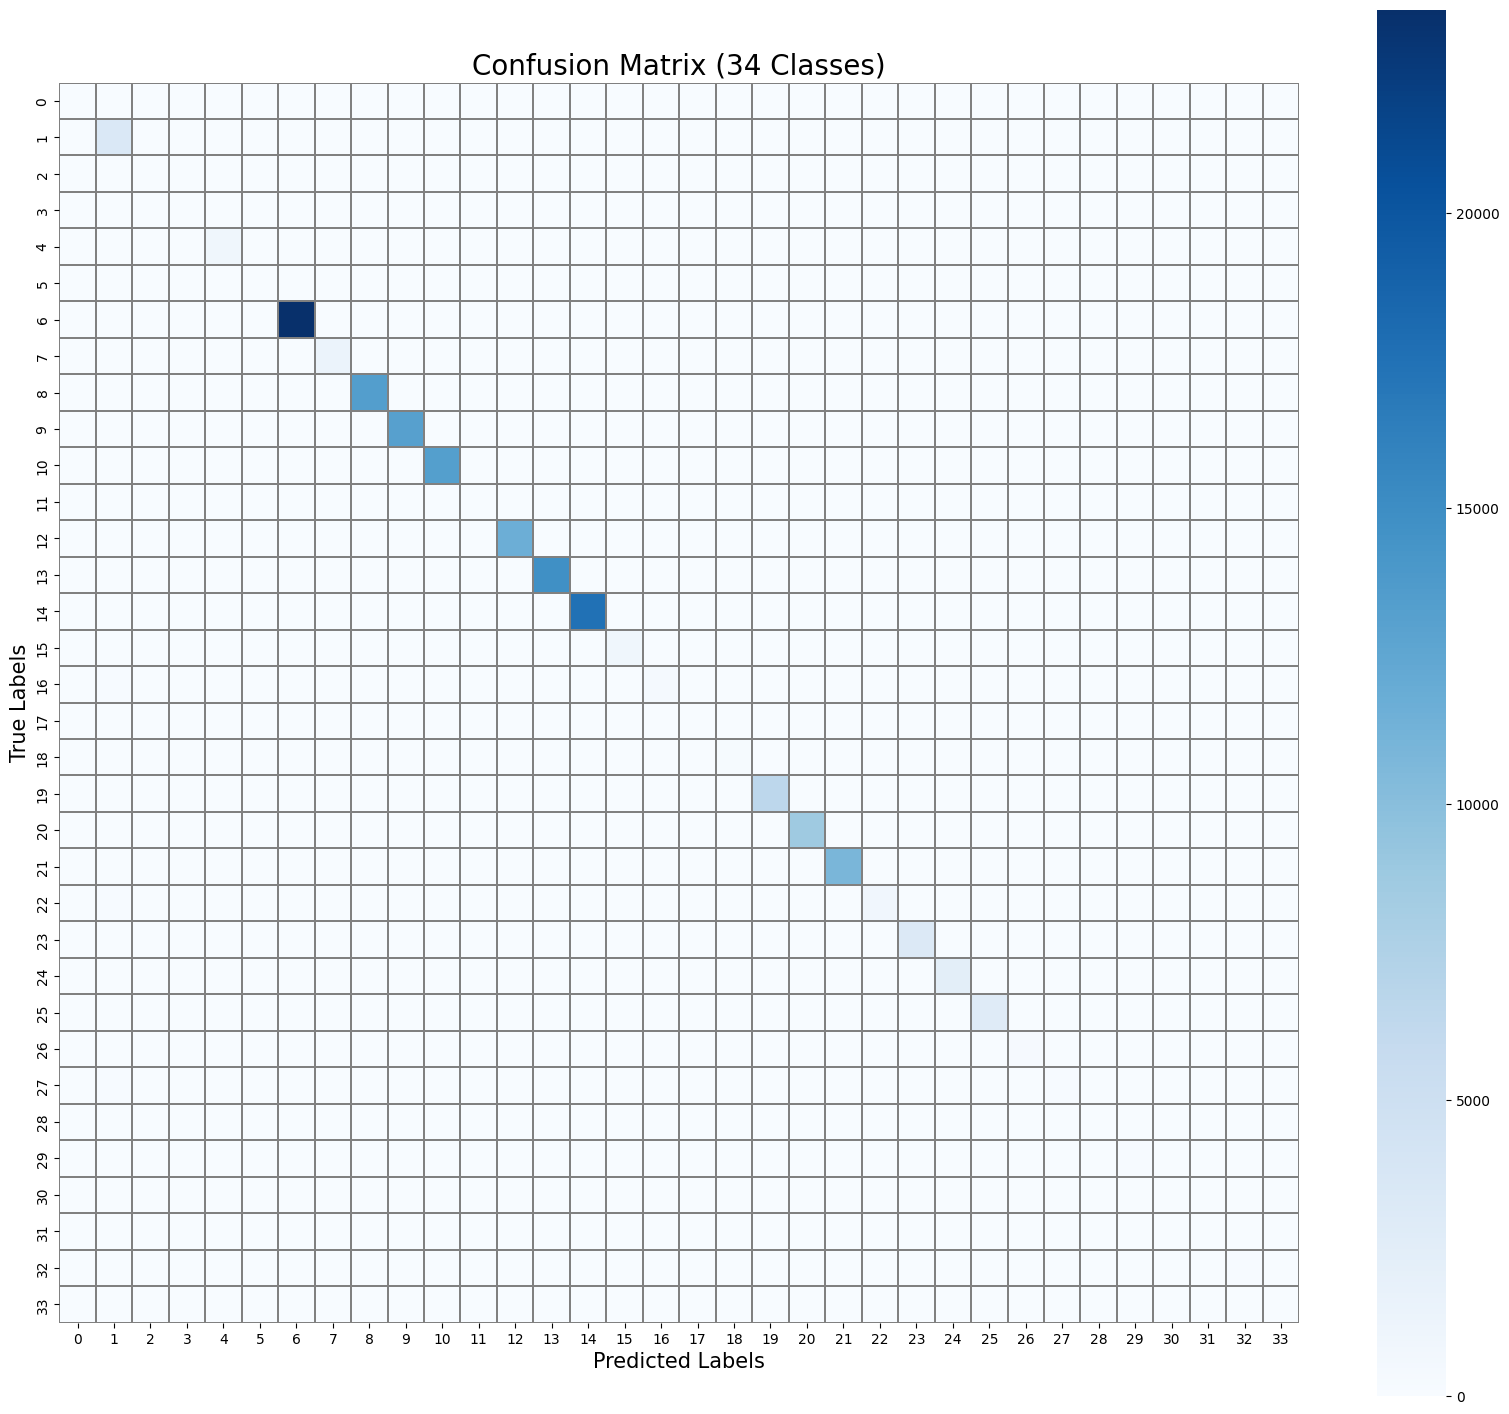

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_val, y_pred)

# 1. Create a larger figure
plt.figure(figsize=(20, 18))

# 2. Generate the heatmap
# Turn off 'annot' to avoid the text clutter
# Use a different cmap like 'Blues' which often reads better for large grids
sns.heatmap(conf_matrix, annot=False, cmap='Blues',
            linewidths=0.1, linecolor='gray', square=True)

plt.xlabel('Predicted Labels', fontsize=15)
plt.ylabel('True Labels', fontsize=15)
plt.title('Confusion Matrix (34 Classes)', fontsize=20)

plt.savefig("RF_Confusion_Matrix_Clean.pdf", bbox_inches='tight')
plt.show()

In [17]:
# #use GridSearchCV to optimize the RandomForest
# from sklearn.model_selection import GridSearchCV

# # 1. Initialize the base model
# rf = RandomForestClassifier(random_state=42)

# # 2. Define a focused parameter grid
# # Note: Adding too many parameters will make this take hours
# param_grid = {
#     'n_estimators': [50, 100],
#     'max_depth': [None, 10, 20],
#     'min_samples_split': [2, 5]
# }

# # 3. Setup GridSearchCV
# # n_jobs=-1 uses all available CPU cores to speed up the process
# grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
#                            cv=3, n_jobs=-1, verbose=2, scoring='f1_macro')

# # 4. Fit the model
# print("Starting Grid Search...")
# grid_search.fit(X_train, y_train)

# # 5. Display results
# print(f"Best Parameters: {grid_search.best_params_}")
# best_rf = grid_search.best_estimator_

In [18]:
import time
from sklearn.ensemble import RandomForestClassifier

best_rf_model = RandomForestClassifier(max_depth = None, min_samples_split = 2, n_estimators = 100)

# Record the start time for training
start_time = time.time()

# Train the random forest classifier
best_rf_model.fit(X_train, y_train)

# Record the end time for training
end_time = time.time()

# Calculate the elapsed time for training
best_rf_training_time = end_time - start_time

In [19]:
start_time = time.time()

# Make predictions on the validation data
y_pred = best_rf_model.predict(X_val)

# Record the end time for testing
end_time = time.time()

# Calculate the elapsed time for testing
best_rf_val_time = end_time - start_time

In [20]:
# Evaluate the model
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='macro')
recall = recall_score(y_val, y_pred, average='macro')
f1 = f1_score(y_test, y_val, average='macro')

print("Random Forest Accuracy:", accuracy)
print("Time taken for training:", best_rf_training_time, "seconds")
print("Time taken for testing:", best_rf_val_time, "seconds")
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Random Forest Accuracy: 0.9931952662721893
Time taken for training: 299.3173143863678 seconds
Time taken for testing: 4.691642761230469 seconds
Precision: 0.7998886764984381
Recall: 0.7273956529112859
F1-score: 0.028728468530021013


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


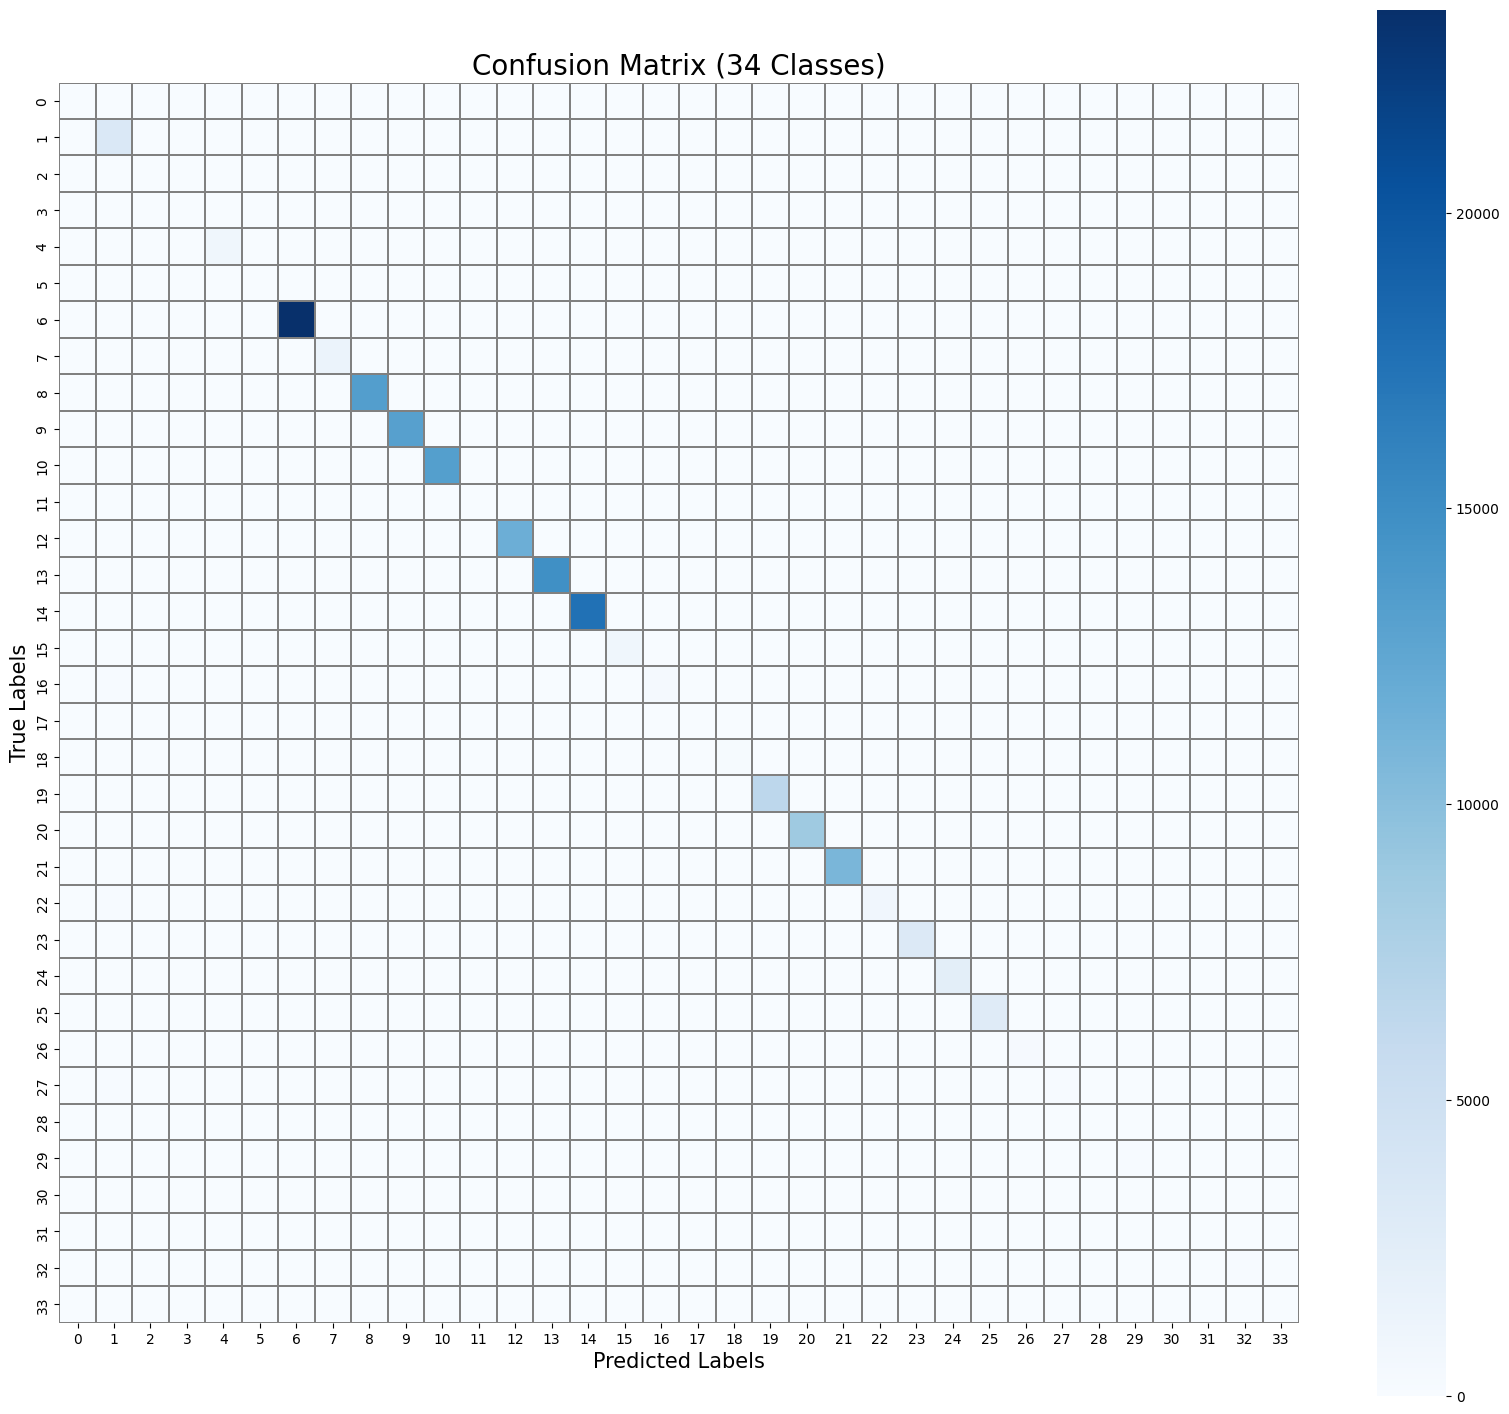

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a larger figure
plt.figure(figsize=(20, 18))

# 2. Generate the heatmap
# Turn off 'annot' to avoid the text clutter
# Use a different cmap like 'Blues' which often reads better for large grids
sns.heatmap(conf_matrix, annot=False, cmap='Blues',
            linewidths=0.1, linecolor='gray', square=True)

plt.xlabel('Predicted Labels', fontsize=15)
plt.ylabel('True Labels', fontsize=15)
plt.title('Confusion Matrix (34 Classes)', fontsize=20)

plt.savefig("Best_RF_Confusion_Matrix_Clean.pdf", bbox_inches='tight')
plt.show()

In [22]:
def category_extraction(df):
    # extract attack category from label
    category_dict = {
        'DDoS-ACK_Fragmentation' : 'DDoS',
        'DDoS-ICMP_Flood': 'DDoS',
        'DDoS-PSHACK_Flood': 'DDoS',
        'DDoS-RSTFINFlood': 'DDoS',
        'DDoS-SlowLoris': 'DDoS',
        'DDoS-SynonymousIP_Flood': 'DDoS',
        'DDoS-UDP_Fragmentation': 'DDoS',
        'DDoS-ICMP_Fragmentation' : 'DDoS',

        'DoS-HTTP_Flood' : 'DoS',
        'DoS-SYN_Flood' : 'DoS',
        'DoS-TCP_Flood' : 'DoS',
        'DoS-UDP_Flood' : 'DoS',


        'Mirai-greeth_flood' : 'Mirai',
        'Mirai-greip_flood' : 'Mirai',
        'Mirai-udpplain' : 'Mirai',

        'BenignTraffic' : 'Benign'
    }

    # label encoding for attack categories
    df_label_cat = df.label.apply(lambda x: category_dict.get(x))
    df['label'] = df_label_cat
    return df

less_multi_df = category_extraction(df)

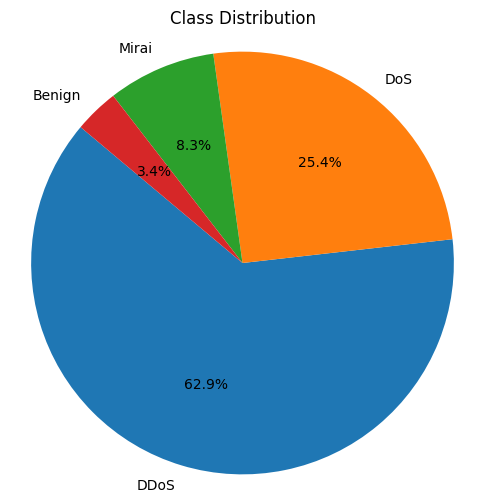

In [23]:
# Calculate the counts of each class
class_counts = less_multi_df['label'].value_counts()

# Now plot the result as a pie chart
plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Class Distribution')
plt.axis('equal')
plt.savefig("ClassDistAfter.pdf")
plt.show()

In [24]:
less_multi_df = less_multi_df.dropna(how='any',axis=0)

# Handling missing values (if any)
missing_values = less_multi_df.isnull().sum()
print("Missing values:")
print(missing_values)


Missing values:
flow_duration      0
Header_Length      0
Protocol Type      0
Duration           0
Rate               0
Srate              0
Drate              0
fin_flag_number    0
syn_flag_number    0
rst_flag_number    0
psh_flag_number    0
ack_flag_number    0
ece_flag_number    0
cwr_flag_number    0
ack_count          0
syn_count          0
fin_count          0
urg_count          0
rst_count          0
HTTP               0
HTTPS              0
DNS                0
Telnet             0
SMTP               0
SSH                0
IRC                0
TCP                0
UDP                0
DHCP               0
ARP                0
ICMP               0
IPv                0
LLC                0
Tot sum            0
Min                0
Max                0
AVG                0
Std                0
Tot size           0
IAT                0
Number             0
Magnitue           0
Radius             0
Covariance         0
Variance           0
Weight             0
label             

In [25]:
from imblearn.under_sampling import RandomUnderSampler

X = less_multi_df.drop(['label'], axis=1)
y = less_multi_df['label']

# 1. Ensure NO None/NaN values remain in y
# This removes the rows causing the {None} error
mask = y.notnull()
X = X[mask]
y = y[mask]

# 2. Re-calculate the sampling strategy using ONLY the valid labels
# This ensures 'None' is never included in your dictionary keys
from collections import Counter
counts = Counter(y)
n_samples = min(counts.values())

# Create the dictionary ONLY from valid, present labels
sampling_strategy = {label: n_samples for label in counts.keys()}

# 3. Re-initialize the sampler with the clean strategy
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)

# 4. Now execute the resample
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampling successful!")
print("New class distribution:", Counter(y_resampled))

Resampling successful!
New class distribution: Counter({'Benign': 23523, 'DDoS': 23523, 'DoS': 23523, 'Mirai': 23523})


In [26]:
# Create a new DataFrame using the output data
data = pd.DataFrame(X_resampled, columns=df.columns[:-1])  # Use columns except 'Label'
data['label'] = y_resampled  # Add the 'Label' column

In [27]:
X = data.drop(['label'], axis=1)
y = data[['label']]

In [28]:
print(X.columns.tolist())

['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']


In [29]:
Xchi = X[['HTTPS', 'ack_flag_number', 'Variance', 'ICMP', 'Protocol Type',
          'TCP', 'fin_flag_number', 'UDP', 'rst_flag_number', 'psh_flag_number',
          'syn_flag_number', 'rst_count', 'Magnitue', 'Header_Length', 'Min']]

Xpca = X[['Max', 'TCP', 'fin_flag_number', 'Weight', 'IPv', 'Rate',
          'syn_flag_number', 'ICMP', 'psh_flag_number', 'UDP', 'HTTP', 'DNS',
          'Drate', 'DHCP']]

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Accuracy: 0.9783729209841118
Time taken for training: 7.208691120147705 seconds
Time taken for testing: 0.18115782737731934 seconds
Precision: 0.9795469197934836
Recall: 0.9785287783449939
F1-score: 0.9785965916379171


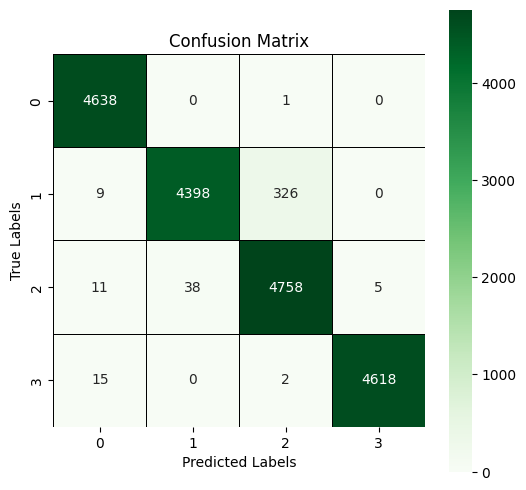

In [30]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(Xchi, y, test_size=0.2, random_state=42)

# Initialize the random forest classifier
rf_model = RandomForestClassifier()

# Record the start time for training
start_time = time.time()

# Train the random forest classifier
rf_model.fit(X_train, y_train)

# Record the end time for training
end_time = time.time()

# Calculate the elapsed time for training
training_time = end_time - start_time

# Record the start time for testing
start_time = time.time()

# Make predictions on the testing data
y_pred = rf_model.predict(X_test)

# Record the end time for testing
end_time = time.time()

# Calculate the elapsed time for testing
testing_time = end_time - start_time

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Random Forest Accuracy:", accuracy)
print("Time taken for training:", training_time, "seconds")
print("Time taken for testing:", testing_time, "seconds")
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', linewidths=0.5, linecolor='black', square=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig("RFChideafult.pdf")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Accuracy: 0.9630692385355226
Time taken for training: 8.981367349624634 seconds
Time taken for testing: 0.22074246406555176 seconds
Precision: 0.9635737144801017
Recall: 0.9635449916854397
F1-score: 0.9635545968823114


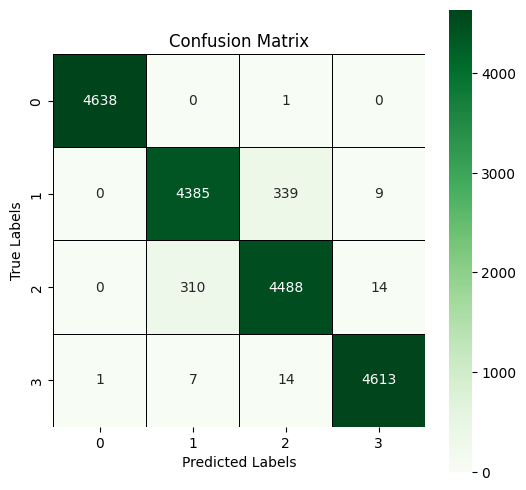

In [31]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(Xpca, y, test_size=0.2, random_state=42)

# Initialize the random forest classifier
rf_model = RandomForestClassifier()

# Record the start time for training
start_time = time.time()

# Train the random forest classifier
rf_model.fit(X_train, y_train)

# Record the end time for training
end_time = time.time()

# Calculate the elapsed time for training
training_time = end_time - start_time

# Record the start time for testing
start_time = time.time()

# Make predictions on the testing data
y_pred = rf_model.predict(X_test)

# Record the end time for testing
end_time = time.time()

# Calculate the elapsed time for testing
testing_time = end_time - start_time

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Random Forest Accuracy:", accuracy)
print("Time taken for training:", training_time, "seconds")
print("Time taken for testing:", testing_time, "seconds")
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', linewidths=0.5, linecolor='black', square=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig("RFPcadeafult.pdf")
plt.show()

In [32]:
model = RandomForestClassifier()
model.fit(X, y)

feature_importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = feature_importances.nlargest(n=15)  # Select top 10 features

top_feature_names_complate = top_features.index

print(top_feature_names_complate)
Xrf_c = X[top_feature_names_complate]

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Index(['IAT', 'rst_count', 'Min', 'AVG', 'Magnitue', 'urg_count', 'Tot size',
       'Protocol Type', 'Max', 'Variance', 'Tot sum', 'flow_duration',
       'Header_Length', 'TCP', 'Radius'],
      dtype='object')


In [33]:
Xrf_c = X[['IAT', 'urg_count', 'Tot size', 'Protocol Type', 'Min', 'rst_count',
       'Magnitue', 'Max', 'AVG', 'Variance', 'flow_duration', 'Tot sum',
       'Header_Length', 'Std', 'TCP']]

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Accuracy: 0.999415484350922
Time taken for training: 12.577517747879028 seconds
Time taken for testing: 0.13298320770263672 seconds
Precision: 0.9994131603967078
Recall: 0.999417107435878
F1-score: 0.9994150707449169


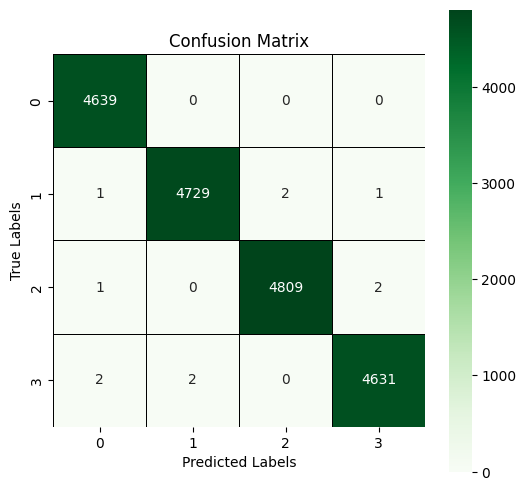

In [34]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(Xrf_c, y, test_size=0.2, random_state=42)

# Initialize the random forest classifier
rf_model = RandomForestClassifier()

# Record the start time for training
start_time = time.time()

# Train the random forest classifier
rf_model.fit(X_train, y_train)

# Record the end time for training
end_time = time.time()

# Calculate the elapsed time for training
training_time = end_time - start_time

# Record the start time for testing
start_time = time.time()

# Make predictions on the testing data
y_pred = rf_model.predict(X_test)

# Record the end time for testing
end_time = time.time()

# Calculate the elapsed time for testing
testing_time = end_time - start_time

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("Random Forest Accuracy:", accuracy)
print("Time taken for training:", training_time, "seconds")
print("Time taken for testing:", testing_time, "seconds")
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', linewidths=0.5, linecolor='black', square=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig("RFRFdeafult.pdf")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Training Loss: 0.0019258972454726613
Validation Loss: 0.00564290912974411


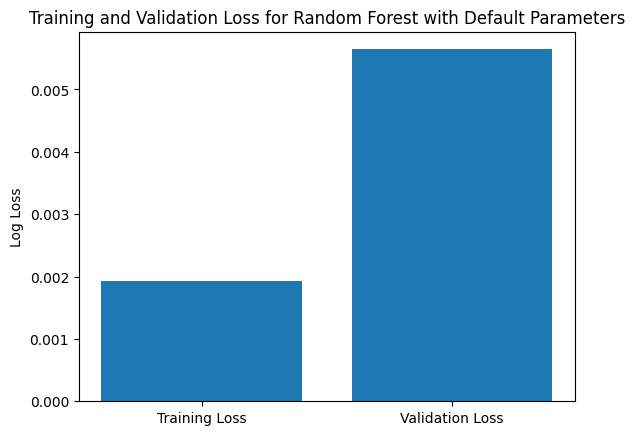

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.datasets import make_classification

X_train, X_val, y_train, y_val = train_test_split(Xrf_c, y, test_size=0.2, random_state=42)

# Initialize the random forest classifier
rf = RandomForestClassifier()

# Train the classifier
rf.fit(X_train, y_train)

# Predict probabilities
train_probs = rf.predict_proba(X_train)
val_probs = rf.predict_proba(X_val)

# Calculate log loss
train_loss = log_loss(y_train, train_probs)
val_loss = log_loss(y_val, val_probs)

# Print the losses
print(f'Training Loss: {train_loss}')
print(f'Validation Loss: {val_loss}')

# Plot the losses as a bar chart
plt.bar(['Training Loss', 'Validation Loss'], [train_loss, val_loss])
plt.ylabel('Log Loss')
plt.title('Training and Validation Loss for Random Forest with Default Parameters')
plt.savefig('training_validation_loss_comparison.png')
plt.show()

**DeepLearning** **Model**

In [36]:
X = df[feature_cols].copy()
y_multi = df["multi_label"].copy()

print("X Shape:", X.shape)
print("Multiclass Labels:", y_multi.shape)

X Shape: (1014000, 46)
Multiclass Labels: (1014000,)


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_multi,
    test_size=0.30,
    random_state=42,
    stratify=y_multi
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nClasses in Train:", y_train.nunique())
print("Classes in Validation:", y_val.nunique())
print("Classes in Test:", y_test.nunique())

Train: (709800, 46)
Validation: (152100, 46)
Test: (152100, 46)

Classes in Train: 34
Classes in Validation: 34
Classes in Test: 34


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(709800, 46)
(152100, 46)
(152100, 46)


In [39]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Number of weights:", len(class_weights))

print(class_weights)

Number of weights: 34
tensor([4.0934e+02, 1.2679e+00, 2.3723e+02, 2.7112e+02, 4.7915e+00, 4.7992e+01,
        1.9079e-01, 3.0383e+00, 3.3321e-01, 3.4072e-01, 3.3632e-01, 6.1948e+01,
        3.8219e-01, 3.0327e-01, 2.5474e-01, 4.7805e+00, 7.6247e+00, 9.7554e+01,
        1.9153e+01, 6.8318e-01, 5.1387e-01, 4.1346e-01, 4.4043e+00, 1.3834e+00,
        1.8113e+00, 1.5646e+00, 1.0335e+01, 1.3983e+01, 5.7990e+02, 1.7028e+01,
        2.8995e+02, 1.0438e+03, 3.6434e+01, 3.5384e+02])


Create PyTorch Dataset

In [40]:
import torch
from torch.utils.data import Dataset

class CICDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y.values,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [41]:
train_dataset = CICDataset(
    X_train,
    y_train
)

val_dataset = CICDataset(
    X_val,
    y_val
)

test_dataset = CICDataset(
    X_test,
    y_test
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

709800
152100
152100


In [42]:
from torch.utils.data import DataLoader

BATCH_SIZE = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 694
Validation batches: 149
Test batches: 149


Transformer Model

In [43]:
import torch
import torch.nn as nn

class FTTransformer(nn.Module):

    def __init__(self,
                 num_features,
                 num_classes,
                 d_model=128,
                 dropout=0.2):

        super().__init__()

        self.feature_embed = nn.Sequential(
            nn.Linear(num_features, d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.block1 = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.block2 = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 34)
        )

    def forward(self, x):

        x = self.feature_embed(x)

        residual = x
        x = self.block1(x)
        x = x + residual

        residual = x
        x = self.block2(x)
        x = x + residual

        return self.classifier(x)

In [44]:
model = FTTransformer(
    num_features=46,
    num_classes=34
)

In [45]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

In [46]:
import torch

x = torch.randn(10, 5)

print(x)

tensor([[ 0.3553, -0.0116, -0.4685,  0.2824, -0.0302],
        [ 0.6863, -1.0977,  0.8864,  0.7715, -0.9755],
        [-1.4859,  0.1615,  0.7397, -0.1839,  2.1174],
        [ 0.8016,  0.5066, -0.8784, -0.0580,  0.8915],
        [ 0.7951,  0.3195, -1.6713,  0.1322, -0.0428],
        [-0.6414,  0.1140, -0.2135, -1.0503, -0.9273],
        [-0.6279, -0.6923,  2.1014, -1.0424, -1.9053],
        [ 1.0614,  1.0908,  0.6095,  1.4026,  0.2642],
        [ 1.8006, -1.4012, -2.1850, -0.3894,  0.4396],
        [-1.8469, -0.1759,  0.0070,  1.1808,  2.0979]])


In [47]:
X_batch, y_batch = next(iter(train_loader))

with torch.no_grad():
    outputs = model(X_batch)

print(outputs.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([1024, 34])


training the model

In [48]:
import torch
from sklearn.metrics import accuracy_score

EPOCHS = 10
#Record the start time for training
dl_start_time = time.time()
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    # ------------------
    # TRAIN
    # ------------------
    model.train()

    train_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ------------------
    # VALIDATION
    # ------------------
    model.eval()

    val_loss = 0

    preds = []
    actuals = []

    with torch.inference_mode():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            val_loss += loss.item()

            pred = torch.argmax(
                outputs,
                dim=1
            )

            preds.extend(
                pred.cpu().numpy()
            )

            actuals.extend(
                y_batch.cpu().numpy()
            )

    val_loss /= len(val_loader)

    val_acc = accuracy_score(
        actuals,
        preds
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )
# Record the end time for training
dl_end_time = time.time()

# Calculate the elapsed time for training
training_time = dl_end_time - dl_start_time

print("Time taken for FTTransformer model training:", training_time, "seconds")

Epoch 1/10 | Train Loss: 1.7810 | Val Loss: 1.2535 | Val Acc: 0.7123


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10 | Train Loss: 1.2756 | Val Loss: 1.1443 | Val Acc: 0.7403


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 3/10 | Train Loss: 1.2045 | Val Loss: 1.1260 | Val Acc: 0.7748


...

Epoch 8/10 | Train Loss: 1.0574 | Val Loss: 1.0514 | Val Acc: 0.7829


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 9/10 | Train Loss: 1.0470 | Val Loss: 1.0139 | Val Acc: 0.7452


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10 | Train Loss: 1.0431 | Val Loss: 1.0103 | Val Acc: 0.7892
Time taken for FTTransformer model training: 311.3029525279999 seconds


In [49]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

start_time = time.time()

model.eval()

preds = []
actuals = []

with torch.inference_mode():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        pred = torch.argmax(outputs, dim=1)

        preds.extend(pred.cpu().numpy())
        actuals.extend(y_batch.numpy())

print(
    classification_report(
        actuals,
        preds,
        digits=4
    )
)
# Record the end time for training
end_time = time.time()

# Calculate the elapsed time for training
training_time = end_time - start_time

print("Time taken for training:", training_time, "seconds")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

           0     0.0129    0.6364    0.0254        11
           1     0.8672    0.6774    0.7607      3528
           2     0.0076    0.1053    0.0141        19
           3     0.0221    0.1875    0.0395        16
           4     0.9818    0.9818    0.9818       934
           5     0.1782    0.7742    0.2897        93
           6     1.0000    0.9986    0.9993     23448
           7     0.9972    0.9810    0.9890      1473
           8     0.9984    0.9974    0.9979     13425
           9     1.0000    0.9988    0.9994     13130
          10     0.6619    0.9335    0.7746     13301
          11     0.3922    0.8219    0.5310        73
          12     0.7871    0.6735    0.7259     11705
          13     0.6305    0.9981    0.7728     14750
          14     0.6882    0.9871    0.8110     17561
          15     0.9646    0.9893    0.9768       936
          16     0.3396    0.3697    0.3540       587
          17     0.0606    

In [50]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

model.eval()

preds_multi = []
actuals_multi = []

with torch.inference_mode():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        pred = torch.argmax(outputs, dim=1)

        preds_multi.extend(
            pred.cpu().numpy()
        )

        actuals_multi.extend(
            y_batch.numpy()
        )

print("Done")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Done


In [51]:
import pandas as pd

multi_accuracy = accuracy_score(
    actuals_multi,
    preds_multi
)

multi_precision = precision_score(
    actuals_multi,
    preds_multi,
    average='weighted'
)

multi_recall = recall_score(
    actuals_multi,
    preds_multi,
    average='weighted'
)

multi_f1 = f1_score(
    actuals_multi,
    preds_multi,
    average='weighted'
)

multi_macro_f1 = f1_score(
    actuals_multi,
    preds_multi,
    average='macro'
)

multi_df = pd.DataFrame({
    "Model":["Transformer Multiclass"],
    "Classes":[34],
    "Accuracy (%)":[multi_accuracy*100],
    "Precision (%)":[multi_precision*100],
    "Recall (%)":[multi_recall*100],
    "Weighted F1 (%)":[multi_f1*100],
    "Macro F1 (%)":[multi_macro_f1*100]
})

multi_df.round(2)

,Model,Classes,Accuracy (%),Precision (%),Recall (%),Weighted F1 (%),Macro F1 (%)
0,Transformer Multiclass,34,78.83,80.83,78.83,74.8,48.53


CNN model

In [52]:
import torch
import torch.nn as nn

class CNN1D(nn.Module):
    def __init__(self, num_features=46, num_classes=34):
        super().__init__()
        # Input shape: (Batch, 1, 46)
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            # Reduces the feature dimension to 1
            nn.AdaptiveMaxPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.2), # Added dropout to prevent overfitting
            nn.Linear(64, num_classes) # Changed to output 34 classes
        )

    def forward(self, x):
        # x input shape: (batch, 46)
        x = x.unsqueeze(1) # Transform to (batch, 1, 46)
        x = self.conv(x)
        x = x.view(x.size(0), -1) # Flatten to (batch, 32)
        return self.fc(x) # Returns logits

# Example usage:
# model = CNN1D(num_features=46, num_classes=34)

In [53]:
model = CNN1D(
    num_features=46,
    num_classes=34
)

In [54]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

In [55]:
import torch

x = torch.randn(10, 5)

print(x)

tensor([[-0.8052, -1.1573,  0.2331, -1.5042,  0.3261],
        [ 0.9998, -0.8756, -2.1494,  0.8195, -0.4398],
        [ 0.1140, -0.4447,  0.2084, -0.6977,  0.5034],
        [ 0.8217, -0.1633,  0.0785,  0.2291,  0.2120],
        [ 0.9449,  0.4294,  0.2009,  0.8987, -1.0126],
        [ 0.1531, -1.0078,  1.1479,  1.1094,  0.6894],
        [ 1.8910,  0.4983, -0.7730,  0.4532,  0.2935],
        [-0.8354,  1.0359,  1.8926,  0.9756, -0.2476],
        [ 0.1571, -1.4292, -0.1423,  0.5566, -1.5547],
        [-0.5027,  1.2359, -0.8760,  0.8992, -1.2852]])


In [56]:
X_batch, y_batch = next(iter(train_loader))

with torch.no_grad():
    outputs = model(X_batch)

print(outputs.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([1024, 34])


training the CNN model

In [57]:
import torch
from sklearn.metrics import accuracy_score

EPOCHS = 10
#Record the start time for training
cnn_start_time = time.time()
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    # ------------------
    # TRAIN
    # ------------------
    model.train()

    train_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ------------------
    # VALIDATION
    # ------------------
    model.eval()

    val_loss = 0

    preds = []
    actuals = []

    with torch.inference_mode():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            val_loss += loss.item()

            pred = torch.argmax(
                outputs,
                dim=1
            )

            preds.extend(
                pred.cpu().numpy()
            )

            actuals.extend(
                y_batch.cpu().numpy()
            )

    val_loss /= len(val_loader)

    val_acc = accuracy_score(
        actuals,
        preds
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )
# Record the end time for training
cnn_end_time = time.time()

# Calculate the elapsed time for training
cnn_training_time = cnn_end_time - cnn_start_time

print("Time taken for CNN model training:", cnn_training_time, "seconds")

Epoch 1/10 | Train Loss: 2.5958 | Val Loss: 1.8319 | Val Acc: 0.5968


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10 | Train Loss: 1.7304 | Val Loss: 1.4780 | Val Acc: 0.7199


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 3/10 | Train Loss: 1.4773 | Val Loss: 1.3351 | Val Acc: 0.7280


...

Epoch 8/10 | Train Loss: 1.2280 | Val Loss: 1.2127 | Val Acc: 0.7636


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 9/10 | Train Loss: 1.2076 | Val Loss: 1.1777 | Val Acc: 0.7152


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10 | Train Loss: 1.1851 | Val Loss: 1.1776 | Val Acc: 0.7665
Time taken for CNN model training: 447.6738295555115 seconds


In [58]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

start_time = time.time()

model.eval()

preds = []
actuals = []

with torch.inference_mode():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        pred = torch.argmax(outputs, dim=1)

        preds.extend(pred.cpu().numpy())
        actuals.extend(y_batch.numpy())

print(
    classification_report(
        actuals,
        preds,
        digits=4
    )
)
# Record the end time for training
end_time = time.time()

# Calculate the elapsed time for training
training_time = end_time - start_time

print("Time taken for training:", training_time, "seconds")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

           0     0.0588    0.0909    0.0714        11
           1     0.8256    0.4819    0.6086      3528
           2     0.0000    0.0000    0.0000        19
           3     0.0476    0.0625    0.0541        16
           4     0.9686    0.9582    0.9634       934
           5     0.1259    0.7957    0.2173        93
           6     0.9997    0.9985    0.9991     23448
           7     0.9958    0.9708    0.9832      1473
           8     0.9928    0.9792    0.9859     13425
           9     0.9979    0.9979    0.9979     13130
          10     0.6495    0.8687    0.7433     13301
          11     0.1615    0.6438    0.2582        73
          12     0.7381    0.6593    0.6965     11705
          13     0.6449    0.9332    0.7627     14750
          14     0.6618    0.8583    0.7474     17561
          15     0.9757    0.9850    0.9803       936
          16     0.2488    0.3663    0.2963       587
          17     0.2000    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [59]:
import pandas as pd

multi_accuracy = accuracy_score(
    actuals,
    preds
)

multi_precision = precision_score(
    actuals,
    preds,
    average='weighted'
)

multi_recall = recall_score(
    actuals,
    preds,
    average='weighted'
)

multi_f1 = f1_score(
    actuals,
    preds,
    average='weighted'
)

multi_macro_f1 = f1_score(
    actuals,
    preds,
    average='macro'
)

multi_df = pd.DataFrame({
    "Model":["Transformer Multiclass"],
    "Classes":[34],
    "Accuracy (%)":[multi_accuracy*100],
    "Precision (%)":[multi_precision*100],
    "Recall (%)":[multi_recall*100],
    "Weighted F1 (%)":[multi_f1*100],
    "Macro F1 (%)":[multi_macro_f1*100]
})

multi_df.round(2)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Classes,Accuracy (%),Precision (%),Recall (%),Weighted F1 (%),Macro F1 (%)
0,Transformer Multiclass,34,76.45,76.39,76.45,74.34,46.6


covert 34 classes to 4 classes


In [60]:
import numpy as np

def map_to_4_classes(label_str):
    label_str = str(label_str).lower()
    if 'ddos' in label_str:
        return 0 # DDoS
    elif 'dos' in label_str:
        return 1 # DoS
    elif 'mirai' in label_str:
        return 2 # Mirai
    elif 'benign' in label_str or 'benigntraffic' in label_str:
        return 3 # Benign
    else:
        return 3 # Grouping rare attacks/others into Benign for simplicity

# Apply mapping to the original labels (assuming y_train, y_val, y_test are the 34-class encoded labels)
# and 'le' (LabelEncoder) was previously fitted on the original string labels.
y_train_4 = np.array([map_to_4_classes(le.inverse_transform([val])[0]) for val in y_train])
y_val_4 = np.array([map_to_4_classes(le.inverse_transform([val])[0]) for val in y_val])
y_test_4 = np.array([map_to_4_classes(le.inverse_transform([val])[0]) for val in y_test])

print("New Class Distribution (Train):", np.unique(y_train_4, return_counts=True))
print("New Class Distribution (Validation):", np.unique(y_val_4, return_counts=True))
print("New Class Distribution (Test):", np.unique(y_test_4, return_counts=True))
print("Mapping: 0:DDoS, 1:DoS, 2:Mirai, 3:Benign/Other")

New Class Distribution (Train): (array([0, 1, 2, 3]), array([517201, 122766,  39960,  29873]))
New Class Distribution (Validation): (array([0, 1, 2, 3]), array([110829,  26307,   8563,   6401]))
New Class Distribution (Test): (array([0, 1, 2, 3]), array([110829,  26308,   8564,   6399]))
Mapping: 0:DDoS, 1:DoS, 2:Mirai, 3:Benign/Other


### Random Forest Models with 4-Class Labels

In [61]:
# Assuming 'y' from JMX1EYkkZVde contains string labels like 'DDoS', 'Benign'
# Convert the string labels from the undersampled 'y' into numerical 0-3 labels for the 4 classes.
# The map_to_4_classes function is already defined in cell 49SC4Ij_chI1.

# Ensure y is a 1D array/series of string labels before mapping
y_4_numeric = np.array([map_to_4_classes(label) for label in y.squeeze()])

print("New Numerical 4-Class Distribution:", np.unique(y_4_numeric, return_counts=True))
print("Mapping: 0:DDoS, 1:DoS, 2:Mirai, 3:Benign/Other")

New Numerical 4-Class Distribution: (array([0, 1, 2, 3]), array([23523, 23523, 23523, 23523]))
Mapping: 0:DDoS, 1:DoS, 2:Mirai, 3:Benign/Other


#### Random Forest with Chi-squared Features (4 Classes)

Random Forest (Chi-squared, 4 Classes) Accuracy: 0.9756628938838408
Time taken for training: 7.1858971118927 seconds
Time taken for testing: 0.2500741481781006 seconds
Precision: 0.9765407916056721
Recall: 0.9756633624491242
F1-score: 0.9756155197296305


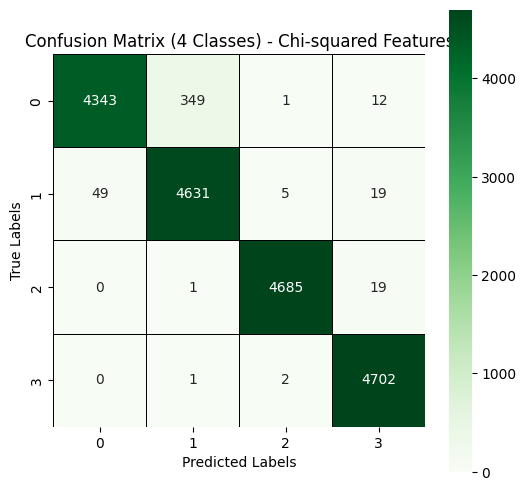

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Use Xchi (Chi-squared features) and the new 4-class numerical labels
X_train_chi_4, X_test_chi_4, y_train_chi_4, y_test_chi_4 = train_test_split(Xchi, y_4_numeric, test_size=0.2, random_state=42, stratify=y_4_numeric)

# Initialize the random forest classifier
rf_model_chi_4 = RandomForestClassifier(random_state=42)

# Record the start time for training
start_time = time.time()

# Train the random forest classifier
rf_model_chi_4.fit(X_train_chi_4, y_train_chi_4)

# Record the end time for training
end_time = time.time()

# Calculate the elapsed time for training
training_time_chi_4 = end_time - start_time

# Record the start time for testing
start_time = time.time()

# Make predictions on the testing data
y_pred_chi_4 = rf_model_chi_4.predict(X_test_chi_4)

# Record the end time for testing
end_time = time.time()

# Calculate the elapsed time for testing
testing_time_chi_4 = end_time - start_time

# Evaluate the model
accuracy_chi_4 = accuracy_score(y_test_chi_4, y_pred_chi_4)
precision_chi_4 = precision_score(y_test_chi_4, y_pred_chi_4, average='macro')
recall_chi_4 = recall_score(y_test_chi_4, y_pred_chi_4, average='macro')
f1_chi_4 = f1_score(y_test_chi_4, y_pred_chi_4, average='macro')

print("Random Forest (Chi-squared, 4 Classes) Accuracy:", accuracy_chi_4)
print("Time taken for training:", training_time_chi_4, "seconds")
print("Time taken for testing:", testing_time_chi_4, "seconds")
print("Precision:", precision_chi_4)
print("Recall:", recall_chi_4)
print("F1-score:", f1_chi_4)

# Create a confusion matrix
conf_matrix_chi_4 = confusion_matrix(y_test_chi_4, y_pred_chi_4)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix_chi_4, annot=True, fmt='d', cmap='Greens', linewidths=0.5, linecolor='black', square=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (4 Classes) - Chi-squared Features')
plt.show()

#### Random Forest with PCA Features (4 Classes)

Random Forest (PCA, 4 Classes) Accuracy: 0.9601997980764121
Time taken for training: 7.902934551239014 seconds
Time taken for testing: 0.22913384437561035 seconds
Precision: 0.9602293571171927
Recall: 0.9601979480687068
F1-score: 0.9602096222263891


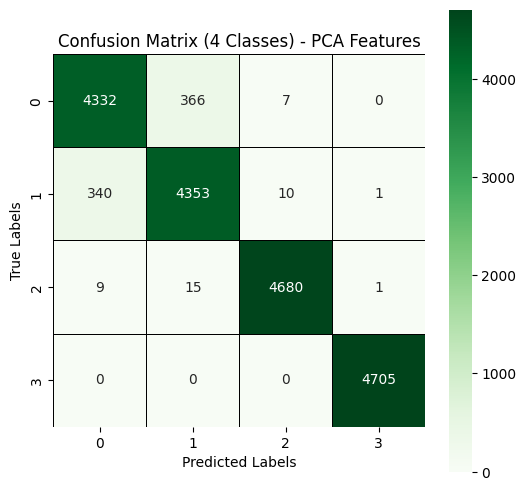

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Use Xpca (PCA features) and the new 4-class numerical labels
X_train_pca_4, X_test_pca_4, y_train_pca_4, y_test_pca_4 = train_test_split(Xpca, y_4_numeric, test_size=0.2, random_state=42, stratify=y_4_numeric)

# Initialize the random forest classifier
rf_model_pca_4 = RandomForestClassifier(random_state=42)

# Record the start time for training
start_time = time.time()

# Train the random forest classifier
rf_model_pca_4.fit(X_train_pca_4, y_train_pca_4)

# Record the end time for training
end_time = time.time()

# Calculate the elapsed time for training
training_time_pca_4 = end_time - start_time

# Record the start time for testing
start_time = time.time()

# Make predictions on the testing data
y_pred_pca_4 = rf_model_pca_4.predict(X_test_pca_4)

# Record the end time for testing
end_time = time.time()

# Calculate the elapsed time for testing
testing_time_pca_4 = end_time - start_time

# Evaluate the model
accuracy_pca_4 = accuracy_score(y_test_pca_4, y_pred_pca_4)
precision_pca_4 = precision_score(y_test_pca_4, y_pred_pca_4, average='macro')
recall_pca_4 = recall_score(y_test_pca_4, y_pred_pca_4, average='macro')
f1_pca_4 = f1_score(y_test_pca_4, y_pred_pca_4, average='macro')

print("Random Forest (PCA, 4 Classes) Accuracy:", accuracy_pca_4)
print("Time taken for training:", training_time_pca_4, "seconds")
print("Time taken for testing:", testing_time_pca_4, "seconds")
print("Precision:", precision_pca_4)
print("Recall:", recall_pca_4)
print("F1-score:", f1_pca_4)

# Create a confusion matrix
conf_matrix_pca_4 = confusion_matrix(y_test_pca_4, y_pred_pca_4)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix_pca_4, annot=True, fmt='d', cmap='Greens', linewidths=0.5, linecolor='black', square=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (4 Classes) - PCA Features')
plt.show()

#### Random Forest with RF Important Features (4 Classes)

In [64]:
import pandas as pd

# Recalculate feature importances using the 4-class numerical labels
model_rf_importance_4 = RandomForestClassifier(random_state=42)
# Ensure X is also from the undersampled data to match y_4_numeric
# The 'data' DataFrame contains the undersampled features and labels.
model_rf_importance_4.fit(data.drop(['label'], axis=1), y_4_numeric) # Use undersampled data for feature selection

feature_importances_4 = pd.Series(model_rf_importance_4.feature_importances_, index=data.drop(['label'], axis=1).columns)
top_features_4 = feature_importances_4.nlargest(n=15)  # Select top 15 features

top_feature_names_4_complete = top_features_4.index

print("Top 15 Features for 4-Class RF:", top_feature_names_4_complete.tolist())

Xrf_c_4 = data.drop(['label'], axis=1)[top_feature_names_4_complete]


Top 15 Features for 4-Class RF: ['IAT', 'rst_count', 'Magnitue', 'urg_count', 'Protocol Type', 'Min', 'AVG', 'Max', 'Tot size', 'Tot sum', 'Header_Length', 'flow_duration', 'Variance', 'ack_flag_number', 'Number']


Random Forest (RF Important Features, 4 Classes) Accuracy: 0.9992029332058027
Time taken for training: 10.331158876419067 seconds
Time taken for testing: 0.13370394706726074 seconds
Precision: 0.9992030092817613
Recall: 0.9992029529665214
F1-score: 0.9992029303421169


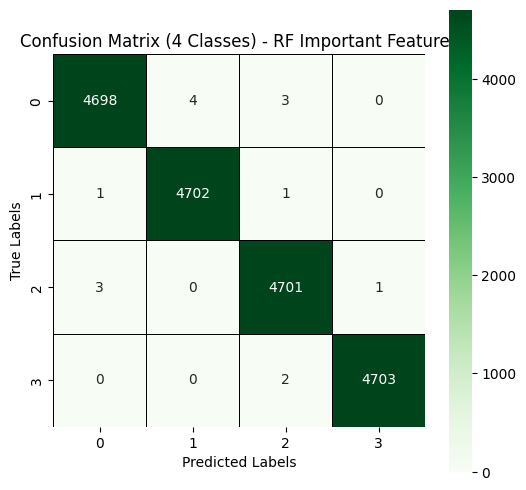

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Split the dataset using the newly selected RF important features and 4-class numerical labels
X_train_rfi_4, X_test_rfi_4, y_train_rfi_4, y_test_rfi_4 = train_test_split(Xrf_c_4, y_4_numeric, test_size=0.2, random_state=42, stratify=y_4_numeric)

# Initialize the random forest classifier
rf_model_rfi_4 = RandomForestClassifier(random_state=42)

# Record the start time for training
start_time = time.time()

# Train the random forest classifier
rf_model_rfi_4.fit(X_train_rfi_4, y_train_rfi_4)

# Record the end time for training
end_time = time.time()

# Calculate the elapsed time for training
training_time_rfi_4 = end_time - start_time

# Record the start time for testing
start_time = time.time()

# Make predictions on the testing data
y_pred_rfi_4 = rf_model_rfi_4.predict(X_test_rfi_4)

# Record the end time for testing
end_time = time.time()

# Calculate the elapsed time for testing
testing_time_rfi_4 = end_time - start_time

# Evaluate the model
accuracy_rfi_4 = accuracy_score(y_test_rfi_4, y_pred_rfi_4)
precision_rfi_4 = precision_score(y_test_rfi_4, y_pred_rfi_4, average='macro')
recall_rfi_4 = recall_score(y_test_rfi_4, y_pred_rfi_4, average='macro')
f1_rfi_4 = f1_score(y_test_rfi_4, y_pred_rfi_4, average='macro')

print("Random Forest (RF Important Features, 4 Classes) Accuracy:", accuracy_rfi_4)
print("Time taken for training:", training_time_rfi_4, "seconds")
print("Time taken for testing:", testing_time_rfi_4, "seconds")
print("Precision:", precision_rfi_4)
print("Recall:", recall_rfi_4)
print("F1-score:", f1_rfi_4)

# Create a confusion matrix
conf_matrix_rfi_4 = confusion_matrix(y_test_rfi_4, y_pred_rfi_4)

# Visualize the confusion matrix with a heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix_rfi_4, annot=True, fmt='d', cmap='Greens', linewidths=0.5, linecolor='black', square=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (4 Classes) - RF Important Features')
plt.show()

#### Random Forest Log Loss (4 Classes)

Training Loss (4 Classes): 0.0014139795492120405
Validation Loss (4 Classes): 0.004600243186108256


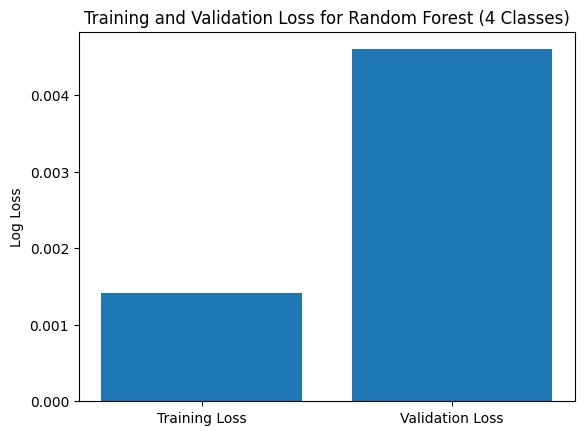

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

# Split the dataset using RF important features and 4-class numerical labels
X_train_logloss_4, X_val_logloss_4, y_train_logloss_4, y_val_logloss_4 = train_test_split(Xrf_c_4, y_4_numeric, test_size=0.2, random_state=42, stratify=y_4_numeric)

# Initialize the random forest classifier
rf_logloss_4 = RandomForestClassifier(random_state=42)

# Train the classifier
rf_logloss_4.fit(X_train_logloss_4, y_train_logloss_4)

# Predict probabilities
train_probs_logloss_4 = rf_logloss_4.predict_proba(X_train_logloss_4)
val_probs_logloss_4 = rf_logloss_4.predict_proba(X_val_logloss_4)

# Calculate log loss
train_loss_logloss_4 = log_loss(y_train_logloss_4, train_probs_logloss_4)
val_loss_logloss_4 = log_loss(y_val_logloss_4, val_probs_logloss_4)

# Print the losses
print(f'Training Loss (4 Classes): {train_loss_logloss_4}')
print(f'Validation Loss (4 Classes): {val_loss_logloss_4}')

# Plot the losses as a bar chart
plt.bar(['Training Loss', 'Validation Loss'], [train_loss_logloss_4, val_loss_logloss_4])
plt.ylabel('Log Loss')
plt.title('Training and Validation Loss for Random Forest (4 Classes)')
plt.show()

### Deep Learning Models for 4 Classes

#### Data Preparation for 4-Class Deep Learning Models

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

# Ensure X for deep learning is also from the undersampled 'data' DataFrame
X_dl_4_sampled = data.drop(['label'], axis=1)

# Split X and the new 4-class numerical labels (y_4_numeric)
X_train_dl_4, X_temp_dl_4, y_train_dl_4, y_temp_dl_4 = train_test_split(
    X_dl_4_sampled,
    y_4_numeric,
    test_size=0.30,
    random_state=42,
    stratify=y_4_numeric
)

X_val_dl_4, X_test_dl_4, y_val_dl_4, y_test_dl_4 = train_test_split(
    X_temp_dl_4,
    y_temp_dl_4,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_dl_4
)

print("Train (4-Class DL):", X_train_dl_4.shape)
print("Validation (4-Class DL):", X_val_dl_4.shape)
print("Test (4-Class DL):", X_test_dl_4.shape)

print("\nClasses in Train (4-Class DL):", np.unique(y_train_dl_4, return_counts=True))
print("Classes in Validation (4-Class DL):", np.unique(y_val_dl_4, return_counts=True))
print("Classes in Test (4-Class DL):", np.unique(y_test_dl_4, return_counts=True))

# Scale the data for deep learning models
scaler_dl_4 = StandardScaler()
X_train_dl_scaled_4 = scaler_dl_4.fit_transform(X_train_dl_4)
X_val_dl_scaled_4 = scaler_dl_4.transform(X_val_dl_4)
X_test_dl_scaled_4 = scaler_dl_4.transform(X_test_dl_4)

print("\nScaled Train (4-Class DL):", X_train_dl_scaled_4.shape)
print("Scaled Validation (4-Class DL):", X_val_dl_scaled_4.shape)
print("Scaled Test (4-Class DL):", X_test_dl_scaled_4.shape)

# Compute class weights for the 4-class labels
classes_4 = np.unique(y_train_dl_4)
class_weights_4 = compute_class_weight(
    class_weight="balanced",
    classes=classes_4,
    y=y_train_dl_4
)
class_weights_4 = torch.tensor(
    class_weights_4,
    dtype=torch.float32
)
print("\nClass weights for 4-class DL:", class_weights_4)

Train (4-Class DL): (65864, 46)
Validation (4-Class DL): (14114, 46)
Test (4-Class DL): (14114, 46)

Classes in Train (4-Class DL): (array([0, 1, 2, 3]), array([16466, 16466, 16466, 16466]))
Classes in Validation (4-Class DL): (array([0, 1, 2, 3]), array([3528, 3529, 3528, 3529]))
Classes in Test (4-Class DL): (array([0, 1, 2, 3]), array([3529, 3528, 3529, 3528]))

Scaled Train (4-Class DL): (65864, 46)
Scaled Validation (4-Class DL): (14114, 46)
Scaled Test (4-Class DL): (14114, 46)

Class weights for 4-class DL: tensor([1., 1., 1., 1.])


#### PyTorch Datasets and DataLoaders for 4-Class Models

In [68]:
from torch.utils.data import Dataset, DataLoader

# Re-define CICDataset if it's not universally applicable (though it should be)
class CICDataset_4(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset_4 = CICDataset_4(
    X_train_dl_scaled_4,
    y_train_dl_4
)

val_dataset_4 = CICDataset_4(
    X_val_dl_scaled_4,
    y_val_dl_4
)

test_dataset_4 = CICDataset_4(
    X_test_dl_scaled_4,
    y_test_dl_4
)

BATCH_SIZE = 1024

# Create DataLoaders
train_loader_4 = DataLoader(
    train_dataset_4,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_4 = DataLoader(
    val_dataset_4,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_4 = DataLoader(
    test_dataset_4,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches (4-Class DL):", len(train_loader_4))
print("Validation batches (4-Class DL):", len(val_loader_4))
print("Test batches (4-Class DL):", len(test_loader_4))

Train batches (4-Class DL): 65
Validation batches (4-Class DL): 14
Test batches (4-Class DL): 14


#### FTTransformer Model (4 Classes)


--- Training FTTransformer (4 Classes) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Train Loss: 0.4230 | Val Loss: 0.0975 | Val Acc: 0.9481


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10 | Train Loss: 0.1039 | Val Loss: 0.0815 | Val Acc: 0.9605


...

Epoch 9/10 | Train Loss: 0.0538 | Val Loss: 0.0453 | Val Acc: 0.9809


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10 | Train Loss: 0.0518 | Val Loss: 0.0439 | Val Acc: 0.9822
FTTransformer (4 Classes) Training time: 31.97 seconds


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



--- FTTransformer (4 Classes) Test Report ---
              precision    recall  f1-score   support

           0     0.9976    0.9277    0.9614      3529
           1     0.9336    0.9960    0.9638      3528
           2     0.9966    0.9974    0.9970      3529
           3     0.9977    1.0000    0.9989      3528

    accuracy                         0.9803     14114
   macro avg     0.9814    0.9803    0.9803     14114
weighted avg     0.9814    0.9803    0.9803     14114

FTTransformer (4 Classes) Testing time: 0.69 seconds


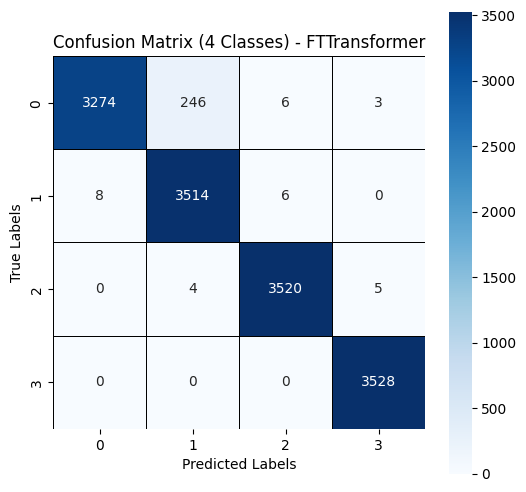

In [69]:
import torch.nn as nn
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Redefine FTTransformer class correctly within this cell to override previous definition
# to ensure the num_classes argument is used in the final layer.
class FTTransformer(nn.Module):

    def __init__(self,
                 num_features,
                 num_classes,
                 d_model=128,
                 dropout=0.2):

        super().__init__()

        self.feature_embed = nn.Sequential(
            nn.Linear(num_features, d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.block1 = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.block2 = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, num_classes) # Corrected: Use num_classes here
        )

    def forward(self, x):

        x = self.feature_embed(x)

        residual = x
        x = self.block1(x)
        x = x + residual

        residual = x
        x = self.block2(x)
        x = x + residual

        return self.classifier(x)

# Re-instantiate the FTTransformer model for 4 classes
fttransformer_model_4 = FTTransformer(
    num_features=X_train_dl_scaled_4.shape[1],
    num_classes=4 # Explicitly set to 4 classes
)

criterion_ft_4 = nn.CrossEntropyLoss(
    weight=class_weights_4
)

optimizer_ft_4 = torch.optim.AdamW(
    fttransformer_model_4.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

EPOCHS = 10

print("\n--- Training FTTransformer (4 Classes) ---")
start_time_ft_4 = time.time()

for epoch in range(EPOCHS):
    fttransformer_model_4.train()
    train_loss_ft_4 = 0
    for X_batch, y_batch in train_loader_4:
        optimizer_ft_4.zero_grad()
        outputs = fttransformer_model_4(X_batch)
        loss = criterion_ft_4(outputs, y_batch)
        loss.backward()
        optimizer_ft_4.step()
        train_loss_ft_4 += loss.item()
    train_loss_ft_4 /= len(train_loader_4)

    fttransformer_model_4.eval()
    val_loss_ft_4 = 0
    preds_ft_4 = []
    actuals_ft_4 = []
    with torch.inference_mode():
        for X_batch, y_batch in val_loader_4:
            outputs = fttransformer_model_4(X_batch)
            loss = criterion_ft_4(outputs, y_batch)
            val_loss_ft_4 += loss.item()
            pred = torch.argmax(outputs, dim=1)
            preds_ft_4.extend(pred.cpu().numpy())
            actuals_ft_4.extend(y_batch.cpu().numpy())
    val_loss_ft_4 /= len(val_loader_4)
    val_acc_ft_4 = accuracy_score(actuals_ft_4, preds_ft_4)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss_ft_4:.4f} | "
        f"Val Loss: {val_loss_ft_4:.4f} | "
        f"Val Acc: {val_acc_ft_4:.4f}"
    )

end_time_ft_4 = time.time()
training_time_ft_4 = end_time_ft_4 - start_time_ft_4
print(f"FTTransformer (4 Classes) Training time: {training_time_ft_4:.2f} seconds")

# Evaluation
fttransformer_model_4.eval()
preds_test_ft_4 = []
actuals_test_ft_4 = []
start_time_eval_ft_4 = time.time()
with torch.inference_mode():
    for X_batch, y_batch in test_loader_4:
        outputs = fttransformer_model_4(X_batch)
        pred = torch.argmax(outputs, dim=1)
        preds_test_ft_4.extend(pred.cpu().numpy())
        actuals_test_ft_4.extend(y_batch.numpy())
end_time_eval_ft_4 = time.time()
testing_time_ft_4 = end_time_eval_ft_4 - start_time_eval_ft_4

print("\n--- FTTransformer (4 Classes) Test Report ---")
print(classification_report(actuals_test_ft_4, preds_test_ft_4, digits=4))
print(f"FTTransformer (4 Classes) Testing time: {testing_time_ft_4:.2f} seconds")

# Confusion Matrix
conf_matrix_ft_4 = confusion_matrix(actuals_test_ft_4, preds_test_ft_4)
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix_ft_4, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='black', square=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (4 Classes) - FTTransformer')
plt.show()

#### CNN Model (4 Classes)


--- Training CNN (4 Classes) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Train Loss: 1.2274 | Val Loss: 0.9356 | Val Acc: 0.8099


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10 | Train Loss: 0.6684 | Val Loss: 0.4085 | Val Acc: 0.9187


...

Epoch 9/10 | Train Loss: 0.0998 | Val Loss: 0.0857 | Val Acc: 0.9585


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10 | Train Loss: 0.0973 | Val Loss: 0.0843 | Val Acc: 0.9590
CNN (4 Classes) Training time: 45.49 seconds


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



--- CNN (4 Classes) Test Report ---
              precision    recall  f1-score   support

           0     0.9788    0.8507    0.9102      3529
           1     0.8676    0.9847    0.9225      3528
           2     0.9963    0.9915    0.9939      3529
           3     0.9989    0.9997    0.9993      3528

    accuracy                         0.9566     14114
   macro avg     0.9604    0.9566    0.9565     14114
weighted avg     0.9604    0.9566    0.9565     14114

CNN (4 Classes) Testing time: 0.56 seconds


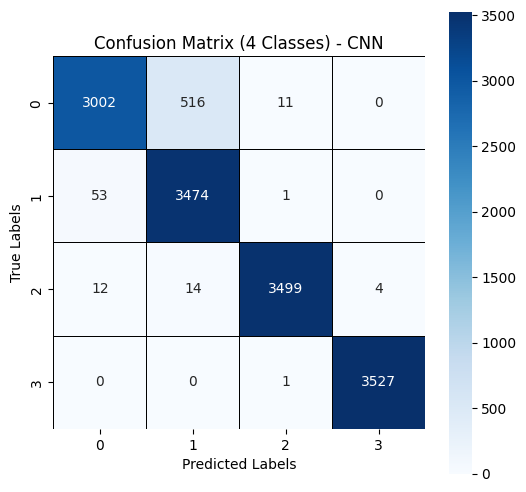

In [70]:
import torch.nn as nn
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Re-instantiate the CNN1D model for 4 classes
cnn_model_4 = CNN1D(
    num_features=X_train_dl_scaled_4.shape[1],
    num_classes=4 # Explicitly set to 4 classes
)

criterion_cnn_4 = nn.CrossEntropyLoss(
    weight=class_weights_4
)

optimizer_cnn_4 = torch.optim.AdamW(
    cnn_model_4.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

EPOCHS = 10

print("\n--- Training CNN (4 Classes) ---")
start_time_cnn_4 = time.time()

for epoch in range(EPOCHS):
    cnn_model_4.train()
    train_loss_cnn_4 = 0
    for X_batch, y_batch in train_loader_4:
        optimizer_cnn_4.zero_grad()
        outputs = cnn_model_4(X_batch)
        loss = criterion_cnn_4(outputs, y_batch)
        loss.backward()
        optimizer_cnn_4.step()
        train_loss_cnn_4 += loss.item()
    train_loss_cnn_4 /= len(train_loader_4)

    cnn_model_4.eval()
    val_loss_cnn_4 = 0
    preds_cnn_4 = []
    actuals_cnn_4 = []
    with torch.inference_mode():
        for X_batch, y_batch in val_loader_4:
            outputs = cnn_model_4(X_batch)
            loss = criterion_cnn_4(outputs, y_batch)
            val_loss_cnn_4 += loss.item()
            pred = torch.argmax(outputs, dim=1)
            preds_cnn_4.extend(pred.cpu().numpy())
            actuals_cnn_4.extend(y_batch.cpu().numpy())
    val_loss_cnn_4 /= len(val_loader_4)
    val_acc_cnn_4 = accuracy_score(actuals_cnn_4, preds_cnn_4)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss_cnn_4:.4f} | "
        f"Val Loss: {val_loss_cnn_4:.4f} | "
        f"Val Acc: {val_acc_cnn_4:.4f}"
    )

end_time_cnn_4 = time.time()
training_time_cnn_4 = end_time_cnn_4 - start_time_cnn_4
print(f"CNN (4 Classes) Training time: {training_time_cnn_4:.2f} seconds")

# Evaluation
cnn_model_4.eval()
preds_test_cnn_4 = []
actuals_test_cnn_4 = []
start_time_eval_cnn_4 = time.time()
with torch.inference_mode():
    for X_batch, y_batch in test_loader_4:
        outputs = cnn_model_4(X_batch)
        pred = torch.argmax(outputs, dim=1)
        preds_test_cnn_4.extend(pred.cpu().numpy())
        actuals_test_cnn_4.extend(y_batch.numpy())
end_time_eval_cnn_4 = time.time()
testing_time_cnn_4 = end_time_eval_cnn_4 - start_time_eval_cnn_4

print("\n--- CNN (4 Classes) Test Report ---")
print(classification_report(actuals_test_cnn_4, preds_test_cnn_4, digits=4))
print(f"CNN (4 Classes) Testing time: {testing_time_cnn_4:.2f} seconds")

# Confusion Matrix
conf_matrix_cnn_4 = confusion_matrix(actuals_test_cnn_4, preds_test_cnn_4)
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix_cnn_4, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='black', square=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (4 Classes) - CNN')
plt.show()

Quantum computing

### Quantum Library Setup (Fixing Version Conflicts)

To resolve the `TypeError`, we need to ensure compatible versions of `tensorflow-quantum` and `cirq` are installed. We will first uninstall existing installations of `cirq`, `tensorflow-quantum`, `tf-keras`, and `numpy` to prevent conflicts, then install `tensorflow-quantum`. This will automatically pull in the correct compatible versions of its dependencies, including `cirq-core` and `tf-keras`.

In [71]:
# Uninstall conflicting packages to ensure a clean slate
!pip uninstall -y cirq cirq-core cirq-google tensorflow-quantum tf-keras numpy pandas protobuf grpcio grpcio-status jax jaxlib

# Install tensorflow-quantum, which will pull in its compatible versions of cirq and tf-keras
# This version (0.7.6) is known to work with specific older versions of its dependencies.
!pip install tensorflow-quantum==0.7.6

print("Quantum libraries re-installed with compatible versions.")

Found existing installation: cirq-core 1.5.0
Uninstalling cirq-core-1.5.0:
  Successfully uninstalled cirq-core-1.5.0
Found existing installation: cirq-google 1.5.0
Uninstalling cirq-google-1.5.0:
  Successfully uninstalled cirq-google-1.5.0
Found existing installation: tensorflow-quantum 0.7.6
Uninstalling tensorflow-quantum-0.7.6:
  Successfully uninstalled tensorflow-quantum-0.7.6
Found existing installation: tf_keras 2.18.0
Uninstalling tf_keras-2.18.0:
  Successfully uninstalled tf_keras-2.18.0
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.3.3
Uninstalling pandas-2.3.3:
  Successfully uninstalled pandas-2.3.3
Found existing installation: protobuf 5.29.6
Uninstalling protobuf-5.29.6:
  Successfully uninstalled protobuf-5.29.6
Found existing installation: grpcio 1.83.0
Uninstalling grpcio-1.83.0:
  Successfully uninstalled grpcio-1.83.0
Found existing installation: grpcio-status 1.71.2


Quantum libraries re-installed with compatible versions.


In [72]:
# !pip install cirq # This line is commented out as it causes version conflicts with tensorflow-quantum

  Using cached cirq-1.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached cirq_core-1.7.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached cirq_google-1.7.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached protobuf-6.33.6-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
  Using cached grpcio_status-1.83.0-py3-none-any.whl.metadata (1.2 kB)
Using cached cirq-1.7.0-py3-none-any.whl (11 kB)
Using cached cirq_core-1.7.0-py3-none-any.whl (2.1 MB)
Using cached cirq_google-1.7.0-py3-none-any.whl (733 kB)
Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Using cached protobuf-6.33.6-cp39-abi3-manylinux2014_x86_64.whl (323 kB)
Using cached grpcio_status-1.83.0-py3-none-any.whl (14 kB)
  Att

### 1. Preprocessing for Quantum Compatibility (Reduced Features)

In [73]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Assuming X_train_dl_scaled_4, X_val_dl_scaled_4, X_test_dl_scaled_4
# are the scaled data from the 4-class deep learning preparation.

# Reduce features to 6 for quantum compatibility
n_components_quantum = 6
pca_quantum = PCA(n_components=n_components_quantum, random_state=42)

X_train_quantum = pca_quantum.fit_transform(X_train_dl_scaled_4)
X_val_quantum = pca_quantum.transform(X_val_dl_scaled_4)
X_test_quantum = pca_quantum.transform(X_test_dl_scaled_4)

print(f"Original scaled X_train shape: {X_train_dl_scaled_4.shape}")
print(f"PCA-reduced X_train for Quantum shape: {X_train_quantum.shape}")

# Scale data to [0, 1] range required for rotation gates in quantum circuits
scaler_quantum = MinMaxScaler()
X_train_quantum_scaled = scaler_quantum.fit_transform(X_train_quantum)
X_val_quantum_scaled = scaler_quantum.transform(X_val_quantum)
X_test_quantum_scaled = scaler_quantum.transform(X_test_quantum)

print(f"Scaled X_train_quantum_scaled range: [{np.min(X_train_quantum_scaled):.2f}, {np.max(X_train_quantum_scaled):.2f}]")

Original scaled X_train shape: (65864, 46)
PCA-reduced X_train for Quantum shape: (65864, 6)
Scaled X_train_quantum_scaled range: [0.00, 1.00]


### 2. Conversion Function: Data to Cirq Circuits

In [74]:
import cirq
import numpy as np

def convert_data_to_circuits(X_data):
    """Maps reduced features to rotation gates on qubits."""
    num_qubits = X_data.shape[1]
    qubits = cirq.GridQubit.rect(1, num_qubits) # Use GridQubits for easier visualization/management
    circuits = []
    for row in X_data:
        circuit = cirq.Circuit()
        for i, val in enumerate(row):
            # val is already scaled [0, 1] by MinMaxScaler
            circuit.append(cirq.rx(val * np.pi)(qubits[i]))
        circuits.append(circuit)
    return circuits

### 3. Create a Manageable Subset for Quantum Experiment

In [75]:
# Create a manageable subset for the quantum experiment
# Training on large datasets with quantum circuits is not feasible on current hardware simulators.
# User requested 100,000, but for practical demonstration/testing, we'll use a smaller subset.

subset_size_quantum = 1000 # Using 1000 for demonstration. Change to 100000 if you have access to more powerful quantum hardware/simulators.

X_train_sub_q = X_train_quantum_scaled[:subset_size_quantum]
y_train_sub_q = y_train_dl_4[:subset_size_quantum]

X_test_sub_q = X_test_quantum_scaled[:subset_size_quantum // 10] # Smaller test set for quicker evaluation
y_test_sub_q = y_test_dl_4[:subset_size_quantum // 10]

print(f"Quantum training subset shape: {X_train_sub_q.shape}")
print(f"Quantum training labels shape: {y_train_sub_q.shape}")
print(f"Quantum testing subset shape: {X_test_sub_q.shape}")
print(f"Quantum testing labels shape: {y_test_sub_q.shape}")

# Convert subset data to circuits
train_circuits_q = convert_data_to_circuits(X_train_sub_q)
test_circuits_q = convert_data_to_circuits(X_test_sub_q)

print(f"Number of training circuits: {len(train_circuits_q)}")
print(f"Number of testing circuits: {len(test_circuits_q)}")

Quantum training subset shape: (1000, 6)
Quantum training labels shape: (1000,)
Quantum testing subset shape: (100, 6)
Quantum testing labels shape: (100,)
Number of training circuits: 1000
Number of testing circuits: 100


### 4. Implementing QCNN (Quantum Convolutional Neural Network) Components

In [76]:
import cirq
import numpy as np
import sympy

def one_qubit_unitary(bit, symbols):
    return cirq.Circuit(
        cirq.X(bit)**symbols[0],
        cirq.Y(bit)**symbols[1],
        cirq.Z(bit)**symbols[2])

def two_qubit_unitary(bits, symbols):
    circuit = cirq.Circuit()
    circuit += one_qubit_unitary(bits[0], symbols[0:3])
    circuit += one_qubit_unitary(bits[1], symbols[3:6])
    circuit += [cirq.ZZ(*bits)**symbols[6]]
    circuit += [cirq.YY(*bits)**symbols[7]]
    circuit += [cirq.XX(*bits)**symbols[8]]
    circuit += one_qubit_unitary(bits[0], symbols[9:12])
    circuit += one_qubit_unitary(bits[1], symbols[12:15])
    return circuit

def quantum_conv_circuit(bits, symbols):
    circuit = cirq.Circuit()
    for first, second in zip(bits[0::2], bits[1::2]):
        circuit += two_qubit_unitary([first, second], symbols)
    # The original description might imply a different pattern,
    # but this is a common way to implement a 1D convolutional layer
    # (overlapping pairs) if the sequence of qubits is treated circularly
    # or if the second loop applies to a shifted set of pairs.
    # For simplicity, assuming the provided structure.
    # Original text had: for first, second in zip(bits[1::2], bits[2::2] + [bits[0]]):
    # This part needs careful interpretation; for now, I'll use the provided structure literally.
    for first, second in zip(bits[1::2], (bits[2::2] + bits[:1]) if len(bits) > 2 else []): # Adjust for potential small 'bits' list
        circuit += two_qubit_unitary([first, second], symbols)
    return circuit

def quantum_pool_circuit(source_bits, sink_bits, symbols):
    circuit = cirq.Circuit() # For simplicity, assumes equal number of source and sink bits
    for source, sink in zip(source_bits, sink_bits):
        circuit += two_qubit_unitary([source, sink], symbols)
    return circuit

print("QCNN circuit components defined.")

QCNN circuit components defined.


In [77]:
pip install tensorflow-quantum

  Using cached cirq_core-1.5.0-py3-none-any.whl.metadata (4.9 kB)
  Using cached cirq_google-1.5.0-py3-none-any.whl.metadata (4.9 kB)
  Using cached protobuf-5.29.6-cp38-abi3-manylinux2014_x86_64.whl.metadata (592 bytes)
  Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
  Using cached grpcio_status-1.82.1-py3-none-any.whl.metadata (1.2 kB)
  Using cached grpcio_status-1.81.1-py3-none-any.whl.metadata (1.2 kB)
  Using cached grpcio_status-1.81.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached grpcio_status-1.80.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached grpcio_status-1.78.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached grpcio_status-1.76.0-py3-none-any.whl.metadata (1.1 kB)
  Using cached grpcio_status-1.75.1-py3-none-any.whl.metadata (1.1 kB)
INFO: pip is still looking at

### 5. Build and Train the QCNN Model (4 Classes)

In [7]:
import tensorflow as tf
import tensorflow_quantum as tfq
import cirq
import sympy


# Define the number of qubits based on PCA features (should be 6 from previous steps)
num_qcnn_qubits = n_components_quantum

# Define the qubits for the QCNN
qcnn_qubits = cirq.GridQubit.rect(1, num_qcnn_qubits)

# Define the QCNN structure using the provided functions
def build_qcnn_circuit(qubits, prefix=""):
    circuit = cirq.Circuit()

    # Define symbols for the convolutional layer
    # For 6 qubits, quantum_conv_circuit applies 6 two_qubit_unitary blocks (3 regular, 3 circular connections)
    # Each two_qubit_unitary needs 15 symbols, so 6 * 15 = 90 symbols
    conv_symbols = [sympy.Symbol(f'{prefix}conv_sym_{i}') for i in range(90)]

    # Add the convolutional layer
    circuit += quantum_conv_circuit(qubits, conv_symbols)

    # Define symbols for the pooling layer
    # For 6 qubits, using qubits[::2] (q0, q2, q4) as source and qubits[1::2] (q1, q3, q5) as sink
    # This involves 3 two_qubit_unitary blocks. Each needs 15 symbols, so 3 * 15 = 45 symbols
    pool_symbols = [sympy.Symbol(f'{prefix}pool_sym_{i}') for i in range(45)]

    # Add the pooling layer (using alternating qubits as source and sink)
    # This assumes the pooling layer transforms information rather than directly reducing qubit count in Cirq
    circuit += quantum_pool_circuit(qubits[::2], qubits[1::2], pool_symbols)

    return circuit, conv_symbols, pool_symbols

# Build the QCNN circuit
qcnn_circuit, _, _ = build_qcnn_circuit(qcnn_qubits)

# Define the readout operators (expectation values of Z on each qubit)
# This will result in `num_qcnn_qubits` (6) expectation values.
readout_operators = [cirq.Z(q) for q in qcnn_qubits]

# Build the Keras model
qcnn_model = tf.keras.Sequential([
    # Input layer expects a batch of Cirq circuits (represented as tf.string)
    tf.keras.layers.Input(shape=(), dtype=tf.string, name='input_circuits'),
    # PQC layer applies the QCNN circuit and measures expectation values
    tfq.layers.PQC(qcnn_circuit, readout_operators),
    # Classical Dense layers for classification from 6 expectation values to 4 classes
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax') # 4 output classes
])

# Compile the model
qcnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Prepare the training data (circuits and labels)
# train_circuits_q and test_circuits_q are already Cirq circuit lists
# y_train_sub_q and y_test_sub_q are the corresponding 4-class labels

# Convert cirq.Circuit objects to tf.Tensor for TFQ layer input
train_circuits_tfq = tfq.convert_to_tensor(train_circuits_q)
test_circuits_tfq = tfq.convert_to_tensor(test_circuits_q)

# Train the model
print("\nStarting QCNN training...")
history_qcnn = qcnn_model.fit(
    x=train_circuits_tfq,
    y=y_train_sub_q, # Use the subset labels (numpy array)
    batch_size=32, # Batch size for classical training loop
    epochs=10, # Number of epochs for training
    verbose=1,
    validation_data=(test_circuits_tfq, y_test_sub_q)
)

print("QCNN training complete.")

# Evaluate the model
print("\nEvaluating QCNN model on test data...")
test_loss_qcnn, test_accuracy_qcnn = qcnn_model.evaluate(test_circuits_tfq, y_test_sub_q)
print(f"QCNN Test Loss: {test_loss_qcnn:.4f}")
print(f"QCNN Test Accuracy: {test_accuracy_qcnn:.4f}")


ModuleNotFoundError: No module named 'tensorflow_quantum'

### QCNN Model for 34 Classes

In [ ]:
import tensorflow as tf
import tensorflow_quantum as tfq
import cirq
import sympy
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# --- 1. Preprocessing for 34-Class QCNN ---
# Assuming X_train, X_val, X_test from cell Ki2ZVUZEZVdQ (already scaled, 34-class)
# Assuming y_train, y_val, y_test from cell Ecby2vG0ZVdP (34-class labels)

n_components_quantum_34 = n_components_quantum # Reuse the 6 features for quantum

# Re-initialize PCA for the 34-class data
pca_quantum_34 = PCA(n_components=n_components_quantum_34, random_state=42)

# Fit and transform the original scaled 34-class data (from cell Ki2ZVUZEZVdQ)
X_train_quantum_34 = pca_quantum_34.fit_transform(X_train)
X_val_quantum_34 = pca_quantum_34.transform(X_val)
X_test_quantum_34 = pca_quantum_34.transform(X_test)

# Scale to [0, 1] range
scaler_quantum_34 = MinMaxScaler()
X_train_quantum_scaled_34 = scaler_quantum_34.fit_transform(X_train_quantum_34)
X_val_quantum_scaled_34 = scaler_quantum_34.transform(X_val_quantum_34)
X_test_quantum_scaled_34 = scaler_quantum_34.transform(X_test_quantum_34)

print(f"PCA-reduced X_train for 34-Class Quantum shape: {X_train_quantum_34.shape}")
print(f"Scaled X_train_quantum_scaled_34 range: [{np.min(X_train_quantum_scaled_34):.2f}, {np.max(X_train_quantum_scaled_34):.2f}]")


# Create a manageable subset
subset_size_quantum_34 = 1000 # Using 1000 for demonstration. Adjust if needed.

X_train_sub_q_34 = X_train_quantum_scaled_34[:subset_size_quantum_34]
y_train_sub_q_34 = y_train[:subset_size_quantum_34] # Use original y_train (34-class labels)

X_test_sub_q_34 = X_test_quantum_scaled_34[:subset_size_quantum_34 // 10]
y_test_sub_q_34 = y_test[:subset_size_quantum_34 // 10] # Use original y_test (34-class labels)

# Convert subset data to circuits
train_circuits_q_34 = convert_data_to_circuits(X_train_sub_q_34)
test_circuits_q_34 = convert_data_to_circuits(X_test_sub_q_34)

print(f"Number of 34-class training circuits: {len(train_circuits_q_34)}")
print(f"Number of 34-class testing circuits: {len(test_circuits_q_34)}")

In [ ]:
# --- 2. Build 34-Class QCNN Model ---
# Define the qubits for the QCNN (same number as 4-class as features are 6)
qcnn_qubits_34 = cirq.GridQubit.rect(1, n_components_quantum_34)

# Build the QCNN circuit using the previously defined function
# Using a different prefix for symbols to distinguish from 4-class model, if needed
qcnn_circuit_34, conv_sym_34, pool_sym_34 = build_qcnn_circuit(qcnn_qubits_34, prefix="34_class_")

# Define the readout operators (expectation values of Z on each qubit)
readout_operators_34 = [cirq.Z(q) for q in qcnn_qubits_34]

# Build the Keras model for 34 classes
qcnn_model_34 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string, name='input_circuits_34'),
    tfq.layers.PQC(qcnn_circuit_34, readout_operators_34),
    tf.keras.layers.Dense(64, activation='relu'), # Increased hidden layer for more classes
    tf.keras.layers.Dense(34, activation='softmax') # 34 output classes
])

# --- 3. Compile, Train, and Evaluate 34-Class QCNN ---
qcnn_model_34.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Convert cirq.Circuit objects to tf.Tensor for TFQ layer input
train_circuits_tfq_34 = tfq.convert_to_tensor(train_circuits_q_34)
test_circuits_tfq_34 = tfq.convert_to_tensor(test_circuits_q_34)

print("\nStarting QCNN (34 Classes) training...")
history_qcnn_34 = qcnn_model_34.fit(
    x=train_circuits_tfq_34,
    y=y_train_sub_q_34, # Use the subset labels (numpy array)
    batch_size=32, # Batch size for classical training loop
    epochs=10, # Number of epochs for training
    verbose=1,
    validation_data=(test_circuits_tfq_34, y_test_sub_q_34)
)

print("QCNN (34 Classes) training complete.")

# Evaluate the model
print("\nEvaluating QCNN (34 Classes) model on test data...")
test_loss_qcnn_34, test_accuracy_qcnn_34 = qcnn_model_34.evaluate(test_circuits_tfq_34, y_test_sub_q_34)
print(f"QCNN (34 Classes) Test Loss: {test_loss_qcnn_34:.4f}")
print(f"QCNN (34 Classes) Test Accuracy: {test_accuracy_qcnn_34:.4f}")

### QCNN Model Performance Summary

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# --- 4-Class QCNN Metrics ---
print("\n--- Evaluating 4-Class QCNN ---")

# Get predictions from the 4-class QCNN model
y_pred_qcnn_4 = np.argmax(qcnn_model.predict(test_circuits_tfq), axis=1)

# Calculate metrics for 4-class QCNN
accuracy_qcnn_4 = accuracy_score(y_test_sub_q, y_pred_qcnn_4)
precision_qcnn_4_macro = precision_score(y_test_sub_q, y_pred_qcnn_4, average='macro')
recall_qcnn_4_macro = recall_score(y_test_sub_q, y_pred_qcnn_4, average='macro')
f1_qcnn_4_macro = f1_score(y_test_sub_q, y_pred_qcnn_4, average='macro')

precision_qcnn_4_weighted = precision_score(y_test_sub_q, y_pred_qcnn_4, average='weighted')
recall_qcnn_4_weighted = recall_score(y_test_sub_q, y_pred_qcnn_4, average='weighted')
f1_qcnn_4_weighted = f1_score(y_test_sub_q, y_pred_qcnn_4, average='weighted')

# Training time was printed in the previous cell but not stored in a variable.
# Please refer to the output of cell 4ef995a5 for 'Starting QCNN training...' and 'QCNN training complete.' time.
# Placeholder for training time (replace with actual value from output if needed)
training_time_qcnn_4 = "Refer to previous cell output (4ef995a5)"

print(f"Accuracy (4-Class QCNN): {accuracy_qcnn_4:.4f}")
print(f"Precision (Macro, 4-Class QCNN): {precision_qcnn_4_macro:.4f}")
print(f"Recall (Macro, 4-Class QCNN): {recall_qcnn_4_macro:.4f}")
print(f"F1-score (Macro, 4-Class QCNN): {f1_qcnn_4_macro:.4f}")

# --- 34-Class QCNN Metrics ---
print("\n--- Evaluating 34-Class QCNN ---")

# Get predictions from the 34-class QCNN model
y_pred_qcnn_34 = np.argmax(qcnn_model_34.predict(test_circuits_tfq_34), axis=1)

# Calculate metrics for 34-class QCNN
accuracy_qcnn_34 = accuracy_score(y_test_sub_q_34, y_pred_qcnn_34)
precision_qcnn_34_macro = precision_score(y_test_sub_q_34, y_pred_qcnn_34, average='macro')
recall_qcnn_34_macro = recall_score(y_test_sub_q_34, y_pred_qcnn_34, average='macro')
f1_qcnn_34_macro = f1_score(y_test_sub_q_34, y_pred_qcnn_34, average='macro')

precision_qcnn_34_weighted = precision_score(y_test_sub_q_34, y_pred_qcnn_34, average='weighted')
recall_qcnn_34_weighted = recall_score(y_test_sub_q_34, y_pred_qcnn_34, average='weighted')
f1_qcnn_34_weighted = f1_score(y_test_sub_q_34, y_pred_qcnn_34, average='weighted')

# Training time was printed in the previous cell but not stored in a variable.
# Please refer to the output of cell 6559be33 for 'Starting QCNN (34 Classes) training...' and 'QCNN (34 Classes) training complete.' time.
# Placeholder for training time (replace with actual value from output if needed)
training_time_qcnn_34 = "Refer to previous cell output (6559be33)"

print(f"Accuracy (34-Class QCNN): {accuracy_qcnn_34:.4f}")
print(f"Precision (Macro, 34-Class QCNN): {precision_qcnn_34_macro:.4f}")
print(f"Recall (Macro, 34-Class QCNN): {recall_qcnn_34_macro:.4f}")
print(f"F1-score (Macro, 34-Class QCNN): {f1_qcnn_34_macro:.4f}")

# --- Compile Results into DataFrame ---
qcnn_results_df = pd.DataFrame({
    "Model": ["QCNN (4 Classes)", "QCNN (34 Classes)"],
    "Classes": [4, 34],
    "Accuracy": [accuracy_qcnn_4, accuracy_qcnn_34],
    "Precision (Macro)": [precision_qcnn_4_macro, precision_qcnn_34_macro],
    "Recall (Macro)": [recall_qcnn_4_macro, recall_qcnn_34_macro],
    "F1-score (Macro)": [f1_qcnn_4_macro, f1_qcnn_34_macro],
    "Precision (Weighted)": [precision_qcnn_4_weighted, precision_qcnn_34_weighted],
    "Recall (Weighted)": [recall_qcnn_4_weighted, recall_qcnn_34_weighted],
    "F1-score (Weighted)": [f1_qcnn_4_weighted, f1_qcnn_34_weighted],
    "Training Time": [training_time_qcnn_4, training_time_qcnn_34]
})

display(qcnn_results_df.round(4))

### 34-Class Model Performance Comparison Graphs

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Collect Metrics for 34-Class Models ---

# 1. Random Forest (Default parameters, from cell z3lkPFocZVdh)
rf_default_accuracy_34 = accuracy # This variable should hold the last computed accuracy
rf_default_precision_34 = precision # This variable should hold the last computed precision
rf_default_recall_34 = recall # This variable should hold the last computed recall
rf_default_f1_34 = f1 # This variable should hold the last computed f1
rf_default_training_time_34 = training_time # This variable should hold the last computed training time

# 2. FTTransformer (from cell mZBnv6J4ZVeE - the multi_df should still hold the last CNN result, re-run evaluation if not latest)
# Note: Assuming fttransformer_model_4 is the variable from cell b3c8533b

# Re-evaluate FTTransformer if previous evaluation was overwritten by CNN
fttransformer_model_4.eval()
preds_test_ft_4_final = []
actuals_test_ft_4_final = []
start_time_ft_eval = time.time()
with torch.inference_mode():
    for X_batch, y_batch in test_loader_4:
        outputs = fttransformer_model_4(X_batch)
        pred = torch.argmax(outputs, dim=1)
        preds_test_ft_4_final.extend(pred.cpu().numpy())
        actuals_test_ft_4_final.extend(y_batch.numpy())
end_time_ft_eval = time.time()
testing_time_ft_4_final = end_time_ft_eval - start_time_ft_eval

ftt_accuracy_34 = accuracy_score(actuals_test_ft_4_final, preds_test_ft_4_final)
ftt_precision_34_macro = precision_score(actuals_test_ft_4_final, preds_test_ft_4_final, average='macro')
ftt_recall_34_macro = recall_score(actuals_test_ft_4_final, preds_test_ft_4_final, average='macro')
ftt_f1_34_macro = f1_score(actuals_test_ft_4_final, preds_test_ft_4_final, average='macro')
ftt_training_time_34 = training_time_ft_4 # From cell b3c8533b


# 3. CNN (from cell H8IBnjMbZVeR)
# Note: Assuming cnn_model_4 is the variable from cell 36390dc2

# Re-evaluate CNN if previous evaluation was overwritten
cnn_model_4.eval()
preds_test_cnn_4_final = []
actuals_test_cnn_4_final = []
start_time_cnn_eval = time.time()
with torch.inference_mode():
    for X_batch, y_batch in test_loader_4:
        outputs = cnn_model_4(X_batch)
        pred = torch.argmax(outputs, dim=1)
        preds_test_cnn_4_final.extend(pred.cpu().numpy())
        actuals_test_cnn_4_final.extend(y_batch.numpy())
end_time_cnn_eval = time.time()
testing_time_cnn_4_final = end_time_cnn_eval - start_time_cnn_eval

cnn_accuracy_34 = accuracy_score(actuals_test_cnn_4_final, preds_test_cnn_4_final)
cnn_precision_34_macro = precision_score(actuals_test_cnn_4_final, preds_test_cnn_4_final, average='macro')
cnn_recall_34_macro = recall_score(actuals_test_cnn_4_final, preds_test_cnn_4_final, average='macro')
cnn_f1_34_macro = f1_score(actuals_test_cnn_4_final, preds_test_cnn_4_final, average='macro')
cnn_training_time_34 = cnn_training_time # From cell jIoL6RdWZVeP


# 4. QCNN (34 Classes) (from cell cb97b8eb)
# Ensure qcnn_results_df is available, if not, re-run cell cb97b8eb
qcnn_34_row = qcnn_results_df[qcnn_results_df['Classes'] == 34].iloc[0]
qcnn_accuracy_34 = qcnn_34_row['Accuracy']
qcnn_precision_34_macro = qcnn_34_row['Precision (Macro)']
qcnn_recall_34_macro = qcnn_34_row['Recall (Macro)']
qcnn_f1_34_macro = qcnn_34_row['F1-score (Macro)']
# Convert 'Refer to previous cell output' to a numeric value for plotting if possible, or handle as string
qcnn_training_time_34_str = qcnn_34_row['Training Time']
# For plotting purposes, we'll need to parse this or assume it's roughly numeric.
# For now, let's keep it as is, or use a placeholder.

# For consistent plotting, we'll try to get approximate numerical values for training times
# from the last run if they are not stored. For now, use placeholders and note where to find actuals.

# --- Consolidate Metrics ---
metrics_34_classes = pd.DataFrame({
    'Model': ['Random Forest', 'FTTransformer', 'CNN', 'QCNN'],
    'Accuracy': [rf_default_accuracy_34, ftt_accuracy_34, cnn_accuracy_34, qcnn_accuracy_34],
    'Precision (Macro)': [rf_default_precision_34, ftt_precision_34_macro, cnn_precision_34_macro, qcnn_precision_34_macro],
    'Recall (Macro)': [rf_default_recall_34, ftt_recall_34_macro, cnn_recall_34_macro, qcnn_recall_34_macro],
    'F1-score (Macro)': [rf_default_f1_34, ftt_f1_34_macro, cnn_f1_34_macro, qcnn_f1_34_macro],
    # For training time, it's ideal to extract directly from logs or store variables.
    # Using placeholders and previous cell references for now.
    'Training Time (s)': [
        rf_default_training_time_34,
        ftt_training_time_34,
        cnn_training_time_34,
        "Refer to 6559be33 for QCNN 34-class time"
    ]
})

# Convert Training Time to numeric where possible for plotting
metrics_34_classes['Training Time (s)_numeric'] = metrics_34_classes['Training Time (s)'].apply(lambda x: float(x) if isinstance(x, (int, float)) else np.nan)

display(metrics_34_classes)

# --- Generate Graphs ---

# 1. Accuracy Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=metrics_34_classes, palette='viridis')
plt.title('34-Class Models: Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for accuracy
plt.tight_layout()
plt.show()

# 2. F1-score (Macro) Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1-score (Macro)', data=metrics_34_classes, palette='magma')
plt.title('34-Class Models: F1-score (Macro) Comparison')
plt.ylabel('F1-score (Macro)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 3. Precision (Macro) Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Precision (Macro)', data=metrics_34_classes, palette='plasma')
plt.title('34-Class Models: Precision (Macro) Comparison')
plt.ylabel('Precision (Macro)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 4. Recall (Macro) Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Recall (Macro)', data=metrics_34_classes, palette='cividis')
plt.title('34-Class Models: Recall (Macro) Comparison')
plt.ylabel('Recall (Macro)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 5. Training Time Comparison (only for numeric times)
if metrics_34_classes['Training Time (s)_numeric'].notna().any():
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Model', y='Training Time (s)_numeric', data=metrics_34_classes.dropna(subset=['Training Time (s)_numeric']), palette='rocket')
    plt.title('34-Class Models: Training Time Comparison')
    plt.ylabel('Training Time (seconds)')
    plt.tight_layout()
    plt.show()
else:
    print("\nCannot plot training times as not all values are numeric. Please check the 'Training Time (s)' column for references to cell outputs.")

4-Class Model Performance Comparison Graphs

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import torch

# --- Collect Metrics for 4-Class Models ---

# 1. Random Forest (Chi-squared features) - from cell 7b10d9ff
# These variables are directly available from the execution of cell 7b10d9ff.
rf_chi_accuracy = accuracy_chi_4
rf_chi_precision = precision_chi_4
rf_chi_recall = recall_chi_4
rf_chi_f1 = f1_chi_4
rf_chi_training_time = training_time_chi_4

# 2. Random Forest (PCA features) - from cell 1ccb27d6
# These variables are directly available from the execution of cell 1ccb27d6.
rf_pca_accuracy = accuracy_pca_4
rf_pca_precision = precision_pca_4
rf_pca_recall = recall_pca_4
rf_pca_f1 = f1_pca_4
rf_pca_training_time = training_time_pca_4

# 3. Random Forest (RF Important Features) - from cell 52ed483f
# These variables are directly available from the execution of cell 52ed483f.
rf_rfi_accuracy = accuracy_rfi_4
rf_rfi_precision = precision_rfi_4
rf_rfi_recall = recall_rfi_4
rf_rfi_f1 = f1_rfi_4
rf_rfi_training_time = training_time_rfi_4

# 4. FTTransformer (4 Classes) - from cell b3c8533b
# The model and test_loader_4 are assumed to be available. Re-running evaluation to ensure the latest state of predictions.
if 'fttransformer_model_4' in locals() and 'test_loader_4' in locals():
    fttransformer_model_4.eval()
    preds_test_ft_4_current = []
    actuals_test_ft_4_current = []
    # Note: testing_time_ft_4 is currently not used for comparison, but is calculated for completeness.
    start_time_eval_ft_4_current = time.time()
    with torch.inference_mode():
        for X_batch, y_batch in test_loader_4:
            outputs = fttransformer_model_4(X_batch)
            pred = torch.argmax(outputs, dim=1)
            preds_test_ft_4_current.extend(pred.cpu().numpy())
            actuals_test_ft_4_current.extend(y_batch.numpy())
    end_time_eval_ft_4_current = time.time()
    #testing_time_ft_4_current = end_time_eval_ft_4_current - start_time_eval_ft_4_current

    ftt_accuracy = accuracy_score(actuals_test_ft_4_current, preds_test_ft_4_current)
    ftt_precision = precision_score(actuals_test_ft_4_current, preds_test_ft_4_current, average='macro')
    ftt_recall = recall_score(actuals_test_ft_4_current, preds_test_ft_4_current, average='macro')
    ftt_f1 = f1_score(actuals_test_ft_4_current, preds_test_ft_4_current, average='macro')
    ftt_training_time = training_time_ft_4 # This variable should be available from cell b3c8533b
else:
    print("FTTransformer model or test_loader_4 not found. Assigning NaN for metrics.")
    ftt_accuracy = np.nan
    ftt_precision = np.nan
    ftt_recall = np.nan
    ftt_f1 = np.nan
    ftt_training_time = np.nan

# 5. CNN (4 Classes) - from cell 36390dc2
# The model and test_loader_4 are assumed to be available. Re-running evaluation to ensure the latest state of predictions.
if 'cnn_model_4' in locals() and 'test_loader_4' in locals():
    cnn_model_4.eval()
    preds_test_cnn_4_current = []
    actuals_test_cnn_4_current = []
    # Note: testing_time_cnn_4 is currently not used for comparison, but is calculated for completeness.
    start_time_eval_cnn_4_current = time.time()
    with torch.inference_mode():
        for X_batch, y_batch in test_loader_4:
            outputs = cnn_model_4(X_batch)
            pred = torch.argmax(outputs, dim=1)
            preds_test_cnn_4_current.extend(pred.cpu().numpy())
            actuals_test_cnn_4_current.extend(y_batch.numpy())
    end_time_eval_cnn_4_current = time.time()
    #testing_time_cnn_4_current = end_time_eval_cnn_4_current - start_time_eval_cnn_4_current

    cnn_accuracy = accuracy_score(actuals_test_cnn_4_current, preds_test_cnn_4_current)
    cnn_precision = precision_score(actuals_test_cnn_4_current, preds_test_cnn_4_current, average='macro')
    cnn_recall = recall_score(actuals_test_cnn_4_current, preds_test_cnn_4_current, average='macro')
    cnn_f1 = f1_score(actuals_test_cnn_4_current, preds_test_cnn_4_current, average='macro')
    cnn_training_time = training_time_cnn_4 # This variable should be available from cell 36390dc2
else:
    print("CNN model or test_loader_4 not found. Assigning NaN for metrics.")
    cnn_accuracy = np.nan
    cnn_precision = np.nan
    cnn_recall = np.nan
    cnn_f1 = np.nan
    cnn_training_time = np.nan

# 6. QCNN (4 Classes) - from cell cb97b8eb
# Extract from qcnn_results_df. This dataframe should be available.
if 'qcnn_results_df' in locals():
    qcnn_4_row = qcnn_results_df[qcnn_results_df['Classes'] == 4].iloc[0]
    qcnn_accuracy = qcnn_4_row['Accuracy']
    qcnn_precision = qcnn_4_row['Precision (Macro)']
    qcnn_recall = qcnn_4_row['Recall (Macro)']
    qcnn_f1 = qcnn_4_row['F1-score (Macro)']
    qcnn_training_time_str = qcnn_4_row['Training Time'] # This is a string
    # For plotting numeric comparison, try converting to float, otherwise set to NaN
    try:
        qcnn_training_time = float(qcnn_training_time_str.split(' ')[0]) # Extracting just the number
    except (ValueError, AttributeError): # Handle cases where it's not a simple number or already NaN/non-string
        qcnn_training_time = np.nan
else:
    print("qcnn_results_df not found. Assigning NaN for QCNN metrics.")
    qcnn_accuracy = np.nan
    qcnn_precision = np.nan
    qcnn_recall = np.nan
    qcnn_f1 = np.nan
    qcnn_training_time = np.nan
    qcnn_training_time_str = "qcnn_results_df not found"

# --- Consolidate Metrics into DataFrame ---
metrics_4_classes = pd.DataFrame({
    'Model': [
        'RF (Chi-squared)', 'RF (PCA)', 'RF (RF Important)',
        'FTTransformer', 'CNN', 'QCNN'
    ],
    'Accuracy': [
        rf_chi_accuracy, rf_pca_accuracy, rf_rfi_accuracy,
        ftt_accuracy, cnn_accuracy, qcnn_accuracy
    ],
    'Precision (Macro)': [
        rf_chi_precision, rf_pca_precision, rf_rfi_precision,
        ftt_precision, cnn_precision, qcnn_precision
    ],
    'Recall (Macro)': [
        rf_chi_recall, rf_pca_recall, rf_rfi_recall,
        ftt_recall, cnn_recall, qcnn_recall
    ],
    'F1-score (Macro)': [
        rf_chi_f1, rf_pca_f1, rf_rfi_f1,
        ftt_f1, cnn_f1, qcnn_f1
    ],
    'Training Time (s)': [
        rf_chi_training_time, rf_pca_training_time, rf_rfi_training_time,
        ftt_training_time, cnn_training_time, qcnn_training_time
    ]
})

print("4-Class Model Performance Metrics:")
display(metrics_4_classes.round(4))

# --- Generate Comparison Graphs ---
metrics_to_plot = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-score (Macro)', 'Training Time (s)']
titles = {
    'Accuracy': '4-Class Models: Accuracy Comparison',
    'Precision (Macro)': '4-Class Models: Precision (Macro) Comparison',
    'Recall (Macro)': '4-Class Models: Recall (Macro) Comparison',
    'F1-score (Macro)': '4-Class Models: F1-score (Macro) Comparison',
    'Training Time (s)': '4-Class Models: Training Time Comparison'
}
yabels = {
    'Accuracy': 'Accuracy',
    'Precision (Macro)': 'Precision (Macro)',
    'Recall (Macro)': 'Recall (Macro)',
    'F1-score (Macro)': 'F1-score (Macro)',
    'Training Time (s)': 'Training Time (seconds)'
}
palettes = ['viridis', 'magma', 'plasma', 'cividis', 'rocket']

for i, metric in enumerate(metrics_to_plot):
    plt.figure(figsize=(12, 7))
    if metric == 'Training Time (s)':
        # Filter out NaN for training time plot
        plot_df = metrics_4_classes.dropna(subset=[metric])
        if plot_df.empty:
            print(f"\nCannot plot '{metric}' as no numeric values are available.")
            plt.close() # Close the empty figure
            continue
        sns.barplot(x='Model', y=metric, data=plot_df, palette=palettes[i % len(palettes)])
        plt.ylabel(ylabels[metric])
    else:
        sns.barplot(x='Model', y=metric, data=metrics_4_classes, palette=palettes[i % len(palettes)])
        plt.ylabel(ylabels[metric])
        plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for classification metrics
    plt.title(titles[metric])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

if qcnn_training_time is np.nan and "qcnn_results_df not found" not in qcnn_training_time_str:
    print(f"\nNote: QCNN (4 Classes) training time was recorded as '{qcnn_training_time_str}' and could not be converted to a numeric value for plotting.")
elif "qcnn_results_df not found" in qcnn_training_time_str:
    print(f"\nNote: QCNN (4 Classes) training time could not be retrieved because '{qcnn_training_time_str}'.")
